# IMPORTS

## Deep Learning & Core API

In [1]:
import tensorflow as tf                     
from tensorflow import keras               
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K   

2025-10-05 14:32:21.694924: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-05 14:32:21.694977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-05 14:32:21.695894: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-05 14:32:21.702095: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Handling & Augmentation

In [2]:
import numpy as np                         
import pandas as pd                         
from sklearn.utils import shuffle           
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Metrics

In [3]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

## Plotting

In [4]:
import matplotlib.pyplot as plt
plt.style.use("default")

## Image Ops

In [5]:
!pip install opencv-python-headless --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import cv2
print(cv2.__version__)

4.12.0


## Experiment Tracking & Env

In [7]:
from comet_ml import Experiment
from dotenv import load_dotenv

## System & Utilities

In [8]:
import os, shutil, datetime, random

# GPU Settings

In [9]:
# List all physical devices available to TensorFlow (CPUs, GPUs, etc.)
devices = tf.config.list_physical_devices()
print("Devices:", devices)

# Query for the default GPU device name (if any)
device_name = tf.test.gpu_device_name()
# If TensorFlow did not detect a GPU at '/device:GPU:0', raise an error
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
# Confirm that the GPU was found
print('Found GPU at: {}'.format(device_name))

# Set the default device context to the GPU for subsequent ops
tf.device('/device:GPU:0')

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


2025-10-05 14:32:31.411588: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:4e:00.0, compute capability: 8.0
2025-10-05 14:32:31.420920: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:4e:00.0, compute capability: 8.0


# Comet Experiment

In [10]:
# Initialize a Comet.ml experiment for tracking metrics, parameters, and model artifacts.
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),         # Your Comet API key stored in an environment variable
    project_name="multi_modal_development",     # Name of the Comet project this experiment belongs to
    auto_histogram_weight_logging=True,         # Automatically log weight distributions after each epoch
    auto_histogram_gradient_logging=True,       # Automatically log gradient distributions after each epoch
    auto_histogram_activation_logging=True,     # Automatically log layer activation distributions after each epoch
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorboard, keras, tensorflow, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/351fb126da0f44c9897778b4cd0d6003



# Directory Setup

In [11]:
# Retrieve the previously logged dataset artifact named "elastography_images" from Comet.ml
logged_artifact = experiment.get_artifact("elastography_images_merged")

# If we haven't already downloaded the images locally, download them now
if not os.path.exists("./Elastography_images"):
    # Download the artifact into the current directory (creates "./Elastography_images" folder)
    local_artifact = logged_artifact.download("./")

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB, Throughput 0 bytes/s, ETA unknown
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


In [12]:
# Set a fixed random seed for reproducibility (e.g., shuffling, augmentations)
seed = 42

# Retrieve the list of class names from the downloaded artifact's metadata
class_names = logged_artifact.metadata["classes"]

# Create an ImageDataGenerator and point it at the local image folder
dataset = ImageDataGenerator().flow_from_directory(
    './Elastography_images',       # Directory containing subfolders per class
    batch_size=1579,               # Load all images in one batch
    class_mode='sparse',           # Return integer labels rather than one‑hot vectors
    target_size=(300, 400),        # Resize every image to 300×400 pixels
    shuffle=False,                 # Keep original ordering (we'll shuffle manually if needed)
    classes=class_names            # Use the provided list of class names (ensures consistent mapping)
)

# Explicitly place data loading on the GPU (if supported and desired)
with tf.device('/device:GPU:0'):
    x, y = dataset.next()         # Load one full batch of (images, labels)

# Report what classes we're working with and how many samples we loaded
print("Classes:", class_names)
print(f"We have {x.shape[0]} total observations")

Found 1578 images belonging to 3 classes.
Classes: ['response', 'stable', 'non-response']
We have 1578 total observations


In [13]:
!pip install openpyxl -q


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# point at the Excel file
excel_path = './clustering_all_v5.xlsx' 

# read it in
df = pd.read_excel(excel_path)

# Quick sanity check: see the first few rows
print(df.head())
df

                                         name  Respone/stable/non-Response  \
0  4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif                            1   
1  4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif                            1   
2    4T1 LOOK DAY29_1C1_1A_cropped_square.tif                            1   
3  4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif                            1   
4    4T1 LOOK DAY29_1C1_1D_cropped_square.tif                            1   

   Elastic Modulus SWE (kPa)  Perfused Area  Cell lines Type of Cancer  \
0                  34.641412        0.624986        4T1         Breast   
1                  23.514638        0.624986        4T1         Breast   
2                  20.450058        0.624986        4T1         Breast   
3                  29.826093        0.793898        4T1         Breast   
4                  22.371027        0.793898        4T1         Breast   

   Therapy  final dimensions  x  final dimensions  y  final dimensions  z  \
0      4.

,name,Respone/stable/non-Response,Elastic Modulus SWE (kPa),Perfused Area,Cell lines,Type of Cancer,Therapy,final dimensions x,final dimensions y,final dimensions z,...,relative volume,stress kPa from comsol,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,1,34.641412,0.624986,4T1,Breast,4.0,8.04,4.30,7.34,...,0.683167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,1,23.514638,0.624986,4T1,Breast,4.0,6.94,4.71,6.20,...,0.419400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,chemotherapy
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,1,20.450058,0.624986,4T1,Breast,4.0,8.52,3.70,4.97,...,0.440482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,immunotherapy
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,1,29.826093,0.793898,4T1,Breast,6.0,7.05,5.32,7.06,...,1.025683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,chemotherapy +immunotherapy
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,1,22.371027,0.793898,4T1,Breast,6.0,8.93,3.78,5.27,...,0.452299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,mechanotheraptutics +chemotherapy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CT_13_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1574,CT_14_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1575,CT_15_M2NR.tif,2,38.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1576,CT_16_M2NR.tif,2,39.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_small = df[['name', 'Elastic Modulus SWE (kPa)']].copy()

In [16]:
## Now refer to them as df_small.filename and df_small.elastic_modulus_kpa, which is shorter and clearer.
df_small.rename(
    columns={
      'name': 'filename',
      'Elastic Modulus SWE (kPa)': 'elastic_modulus_kpa'
    },
    inplace=True
)

# fix in-place:
df_small['filename'] = df_small['filename'].str.replace('\u03A4', 'T')

In [17]:
df_small

,filename,elastic_modulus_kpa
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,34.641412
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,23.514638
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,20.450058
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,29.826093
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,22.371027
...,...,...
1573,CT_13_M2NR.tif,42.410000
1574,CT_14_M2NR.tif,42.410000
1575,CT_15_M2NR.tif,38.500000
1576,CT_16_M2NR.tif,39.030000


# Quality Checks

In [18]:
# Sanity‐check shapes
print(f"x.shape      = {x.shape}")   # e.g. (1365, 300, 400, 3)
print(f"y.shape      = {y.shape}")   # e.g. (1365,)
print(f"n filenames  = {len(dataset.filenames)}")

x.shape      = (1578, 300, 400, 3)
y.shape      = (1578,)
n filenames  = 1578


In [19]:
# Peek at the first 5 filenames and their labels
print("\nFirst 5 samples:")
for i in range(5):
    fn = dataset.filenames[i]
    print(f"  idx={i:3d}: file='{fn}',  y={y[i]}")


First 5 samples:
  idx=  0: file='response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif',  y=0.0
  idx=  1: file='response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif',  y=0.0
  idx=  2: file='response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif',  y=0.0
  idx=  3: file='response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif',  y=0.0
  idx=  4: file='response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif',  y=0.0


In [20]:
# Check every filename is in your Excel lookup
excel_files = set(df_small['filename'])
missing = [fn for fn in dataset.filenames if fn not in excel_files]
print(f"\nLookup check: {len(missing)} filenames NOT in df_small:")
print(missing[:10])  # show up to first 10 missing, if any


Lookup check: 1578 filenames NOT in df_small:
['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


# Combining the images with the numerical data

In [21]:
# Get the exact file‐order that produced x and y

files_in_order = dataset.filenames
print(files_in_order[:10])

['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


 This line gets a list of the full file paths of all the images that ImageDataGenerator loaded into your x numpy array. The key here is that this list is in the exact same order as the images are arranged in the x array. This list is your reference for the image order.

In [22]:
# Drop the class prefix to match your Excel keys

basenames = [os.path.basename(p) for p in files_in_order]

Your Excel file's 'name' column likely contains just the filename without the directory structure (like 'response/' or 'stable/'). This line uses os.path.basename() to strip off that directory prefix from each file path in files_in_order. The basenames list now contains just the filenames, and critically, it's still in the same order as the images in x and the labels in y.

In [23]:
# Build filename → kPa lookup from df_small

num_map = dict(zip(
    df_small['filename'],
    df_small['elastic_modulus_kpa']
))

This creates a Python dictionary. It takes the 'filename' column from your df_small DataFrame (which contains the base filenames from your Excel data) and pairs each filename with its corresponding 'elastic_modulus_kpa' value. This dictionary acts as a quick lookup table: you can give it a filename, and it returns the Elastic Modulus for that file according to your Excel data.

In [24]:
# Create X_num in the same sequence as x, y
X_num = np.array([num_map[b] for b in basenames],
                 dtype=np.float32).reshape(-1, 1)

# Verify shapes all match
assert x.shape[0] == X_num.shape[0] == y.shape[0], \
    f"Shape mismatch: x={x.shape[0]}, X_num={X_num.shape[0]}, y={y.shape[0]}"

# Spot-check a few samples
for i in [0, 10, 100, 500, 698, 748]:
    fname = basenames[i]
    print(f"idx={i:3d}:")
    print("  file:", fname)
    print("  label:", y[i])
    print("  numeric (kPa):", X_num[i,0])
    print("  expected kPa from df_small:", num_map[fname])
    print("---")

idx=  0:
  file: 4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 34.64141
  expected kPa from df_small: 34.6414115585445
---
idx= 10:
  file: 4T1 LOOK DAY29_1C1_2D_cropped_square.tif
  label: 0.0
  numeric (kPa): 31.362246
  expected kPa from df_small: 31.3622458206534
---
idx=100:
  file: 4T1-BOSENTAN 10-CAGE101A_cropped_square.tif
  label: 0.0
  numeric (kPa): 28.774137
  expected kPa from df_small: 28.7741366905846
---
idx=500:
  file: E0771_TRAN_MIC_DAY14C5_2D_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 24.397993
  expected kPa from df_small: 24.3979927820739
---
idx=698:
  file: 4T1-BOSENTA_IMM_-IMMUNOC5_NONE_c_cropped_square.tif
  label: 1.0
  numeric (kPa): 32.10513
  expected kPa from df_small: 32.1051289621743
---
idx=748:
  file: B6-BOSENTA _IMM_ CONTROLC2_1A_cropped_square.tif
  label: 1.0
  numeric (kPa): 47.269875
  expected kPa from df_small: 47.2698756948572
---


X_num = np.array([num_map[b] for b in basenames], dtype=np.float32).reshape(-1, 1): This is the core alignment step. It iterates through the basenames list (which is in the correct order matching x and y). For each filename b in this list, it uses the num_map dictionary to retrieve the associated elastic_modulus_kpa value from your Excel data. These retrieved numerical values are collected into a new list, which is then converted into a numpy array X_num. Because we iterated through basenames (which is aligned with x and y), the X_num array is now also aligned with x and y. reshape(-1, 1) just ensures the numerical data is in the correct 2D shape expected for a single numerical feature input (num_samples, 1).
Assertions and Spot-checks: The assert statement programmatically confirms that the number of samples in your image array (x), the newly created numerical array (X_num), and your label array (y) are all the same. This is a vital check that the alignment process didn't lose or duplicate samples. The spot-check loop then allows you to manually inspect a few samples, printing the filename, label (from y), the numerical value you just put into X_num, and the expected numerical value directly from your Excel lookup (num_map[fname]). If these match for the checked indices, it gives you high confidence that the alignment is correct.

# CHECKS

## Shape check — makes sure you have exactly one numeric value and one label per image.

In [25]:
# SHAPE CHECK — every image must have a numeric value and a label
print("Shape of x:",      x.shape)
print("Shape of X_num:",  X_num.shape)
print("Shape of y:",      y.shape)
assert x.shape[0] == X_num.shape[0] == y.shape[0], "❌ Mismatch in sample counts!"

Shape of x: (1578, 300, 400, 3)
Shape of X_num: (1578, 1)
Shape of y: (1578,)


## Missing‐key check — ensures every image file in x was found in your Excel table.

In [26]:
# MISSING KEY CHECK — ensure every basename was in your Excel lookup
excel_files = set(df_small['filename'])
missing = [b for b in basenames if b not in excel_files]
print(f"\nMissing in Excel lookup: {len(missing)} files")
if missing:
    print("Examples:", missing[:5])
else:
    print("✅ All basenames found in Excel")


Missing in Excel lookup: 0 files
✅ All basenames found in Excel


## Merge‐back spot‐check — reconstructs a mini‐DataFrame combining your aligned kPa (kpa_aligned) with the original Excel kPa (kpa_excel) so you can detect any discrepancies.

In [27]:
# MERGE‐BACK SPOT‐CHECK — pull everything into one DataFrame and compare
df_qc = pd.DataFrame({
    'basename': basenames,
    'y_keras':   y.astype(int),
    'kpa_aligned': X_num.flatten()
})
# bring in the true Excel kPa and label, via a merge
df_qc = df_qc.merge(
    df_small.rename(columns={'filename':'basename'}),
    on='basename',
    how='left'
).rename(columns={
    'elastic_modulus_kpa':'kpa_excel',
    # if you have Excel label column, rename it here
    'Respone/stable/non-Response':'label_excel'
})

# show any rows where the two kPa disagree
df_mis = df_qc[np.abs(df_qc['kpa_aligned'] - df_qc['kpa_excel']) > 1e-6]
print(f"\nRows where aligned kPa ≠ Excel kPa: {len(df_mis)}")
if len(df_mis):
    print(df_mis.head())


Rows where aligned kPa ≠ Excel kPa: 485
                                      basename  y_keras  kpa_aligned  \
6   4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif        0    32.665905   
8   4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif        0    33.584015   
28  4T1 LOOK_BOS+TRAC1_1D_c_cropped_square.tif        0    32.790493   
59       4T1 LOOK_DAY23C3_b_cropped_square.tif        0    32.713615   
67  4T1 LOOK_DAY23C7_NONE_c_cropped_square.tif        0    33.497814   

    kpa_excel  
6   32.665903  
8   33.584016  
28  32.790495  
59  32.713614  
67  33.497813  


## Random spot‐checks — prints out 5 random examples to eyeball that the file, label, and numeric values match.

In [28]:
# 4) RANDOM SPOT‐CHECK — sample a few random indices
print("\nRandom spot‐checks:")
for i in np.random.choice(len(df_qc), size=5, replace=False):
    row = df_qc.iloc[i]
    print(f" idx={i}, file={row.basename}")
    print(f"   y_keras={row.y_keras},  kpa_aligned={row.kpa_aligned:.4f},  kpa_excel={row.kpa_excel:.4f}")
    if 'label_excel' in df_qc.columns:
        print(f"   label_excel={int(row.label_excel)-1} (minus 1 if you zero‐indexed it)")
    print("---")


Random spot‐checks:
 idx=315, file=B6-BOSENTAN_IMM_-iMMUC6_1A_cropped_square.tif
   y_keras=0,  kpa_aligned=21.6697,  kpa_excel=21.6697
---
 idx=80, file=4T1-BOSENTAN 0.2-CAGE4NONE_cropped_square.tif
   y_keras=0,  kpa_aligned=33.2914,  kpa_excel=33.2914
---
 idx=1326, file=B6-BOSENTNA_IMM_-BOSENTANC4_1D_f_cropped_square.tif
   y_keras=2,  kpa_aligned=48.8349,  kpa_excel=48.8349
---
 idx=284, file=B6-BOSENTAN-10-CAGE10UNKNOWN_c_cropped_square.tif
   y_keras=0,  kpa_aligned=23.5167,  kpa_excel=23.5167
---
 idx=465, file=E0771_TRAN_MIC_DAY11C17_1A_b_cropped_square.tif
   y_keras=0,  kpa_aligned=34.1339,  kpa_excel=34.1339
---


## Distribution check — compares summary statistics (count, mean, std, min, max) of the kPa values from the raw Excel table vs. your aligned array

In [29]:
# DISTRIBUTION CHECK — compare kPa distributions from your Excel vs aligned
print("\nkPa summary (Excel):")
print(df_small['elastic_modulus_kpa'].describe().round(3))
print("\nkPa summary (aligned array):")
print(pd.Series(X_num.flatten()).describe().round(3))


kPa summary (Excel):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
Name: elastic_modulus_kpa, dtype: float64

kPa summary (aligned array):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
dtype: float64


## Label distribution check — compares the class counts from Keras (y) vs. the Excel labels (if you merged them too).

In [30]:
# LABEL DISTRIBUTION CHECK — ensure your y array matches folder counts
print("\nClass counts from Keras (y):")
print(pd.Series(y.astype(int)).value_counts().sort_index())
if 'label_excel' in df_qc.columns:
    print("\nClass counts from Excel:")
    print(df_qc['label_excel'].value_counts().sort_index())


Class counts from Keras (y):
0    573
1    492
2    513
Name: count, dtype: int64


## Shuffle & Split

In [31]:
# ──────────── CHUNK 0: Imports & initial train/test split ────────────

from sklearn.utils           import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Shuffle everything first
SEED = 42
X_img_all, X_num_all, y_all = shuffle(
    x,        # image array
    X_num,    # numeric kPa array
    y,        # labels
    random_state=SEED
)

# Split off the TEST set (15% of the original data)
test_frac = 0.15
X_img_temp, X_img_test, X_num_temp, X_num_test, y_temp, y_test = train_test_split(
    X_img_all,
    X_num_all,
    y_all,
    test_size=test_frac,
    random_state=SEED,
    shuffle=True,
    stratify=y_all
)

# Split the remaining 85% into TRAIN (70%) and VAL (15%)
val_rel = 0.15 / (1 - test_frac)
X_img_train, X_img_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_img_temp,
    X_num_temp,
    y_temp,
    test_size=val_rel,
    random_state=SEED,
    shuffle=True,
    stratify=y_temp
)

# Standardize the numeric feature using only the TRAIN stats
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_val   = scaler.transform(X_num_val)
X_num_test  = scaler.transform(X_num_test)

# Confirm shapes
print(f"Train   images: {X_img_train.shape}   numeric: {X_num_train.shape}   labels: {y_train.shape}")
print(f"Val     images: {X_img_val.shape}     numeric: {X_num_val.shape}     labels: {y_val.shape}")
print(f"Test    images: {X_img_test.shape}    numeric: {X_num_test.shape}    labels: {y_test.shape}")

Train   images: (1104, 300, 400, 3)   numeric: (1104, 1)   labels: (1104,)
Val     images: (237, 300, 400, 3)     numeric: (237, 1)     labels: (237,)
Test    images: (237, 300, 400, 3)    numeric: (237, 1)    labels: (237,)


## Images and kPa values remain correctly paired

In [32]:
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import os

# Original ordered basenames (before shuffle)
files_all = np.array(basenames)   # basenames = [os.path.basename(p) for p in dataset.filenames]

# Create the shuffled filenames using the same seed
#    This applies the *same* permutation as your earlier shuffle(x, X_num, y).
files_shuf = shuffle(files_all, random_state=SEED)

# Spot-check a few random samples to confirm alignment
idxs = np.random.RandomState(SEED).choice(len(y_all), size=5, replace=False)
for i in idxs:
    fn       = files_shuf[i]
    kpa_seen = float(X_num_all[i, 0])
    kpa_true = float(num_map[fn])
    print(f"Index {i}:")
    print(f"  file        = {fn}")
    print(f"  shuffled kPa = {kpa_seen:.3f}")
    print(f"  expected kPa = {kpa_true:.3f}")
    assert np.isclose(kpa_seen, kpa_true, atol=1e-6), f"Mismatch at index {i}"
    # Optional visual check
    # plt.imshow(X_img_all[i].astype('uint8'))
    # plt.title(f"{fn}\n{kpa_seen:.1f} vs {kpa_true:.1f} kPa")
    # plt.axis('off')
    # plt.show()

print("✅ All checks passed: images and kPa values remain correctly paired.")

Index 1239:
  file        = E0771_TRA_MIC_DOSE_DAYDAY16C2_1A_cropped_square.tif
  shuffled kPa = 59.869
  expected kPa = 59.869
Index 813:
  file        = B6-BOSENTAN_IMM_-IMMU_CC5_1A_b_cropped_square.tif
  shuffled kPa = 27.433
  expected kPa = 27.433
Index 1174:
  file        = B6-BOSENTAN 0.2-CAGE31A_cropped_square.tif
  shuffled kPa = 22.873
  expected kPa = 22.873
Index 534:
  file        = 4T1 LOOK_BOS+TRAC9_1A_cropped_square.tif
  shuffled kPa = 33.151
  expected kPa = 33.151
Index 514:
  file        = B6-BOSENTNA_IMM_-CONTROLC2_1D_b_cropped_square.tif
  shuffled kPa = 41.931
  expected kPa = 41.931
✅ All checks passed: images and kPa values remain correctly paired.


# CNN model - augmentation (multi) 

In [33]:
# tf.data pipeline & dataset instantiation
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED                  = 42
IMG_HEIGHT, IMG_WIDTH = 304, 400   # multiples of 16
BATCH_SIZE            = 32
AUTOTUNE              = tf.data.AUTOTUNE

def preprocess(image, numeric, label):
    # Ensure shapes & dtypes are friendly
    image   = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image   = tf.cast(image, tf.float32) / 255.0         # [0,1]
    image   = tf.clip_by_value(image, 0.0, 1.0)
    numeric = tf.cast(numeric, tf.float32)
    label   = tf.cast(label, tf.int64)
    return (image, numeric), label

data_augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.05),
    ],
    name="data_augmentation",
)

def augment(inputs, label):
    # Inputs arrive as a tuple from preprocess: (image, numeric)
    image, numeric = inputs
    image = data_augment(image)      # augment on float images in [0,1]
    return (image, numeric), label

def make_dataset(images, numerics, labels, shuffle=False, augment_data=False, cache=False):
    # Build the dataset from numpy arrays
    with tf.device('/CPU:0'):
        ds = tf.data.Dataset.from_tensor_slices((images, numerics, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# Instantiate your sets (cache val/test for speed)
train_set = make_dataset(X_img_train, X_num_train, y_train, shuffle=True,  augment_data=True,  cache=False)
val_set   = make_dataset(X_img_val,   X_num_val,   y_val,   shuffle=False, augment_data=False, cache=True)
test_set  = make_dataset(X_img_test,  X_num_test,  y_test,  shuffle=False, augment_data=False, cache=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

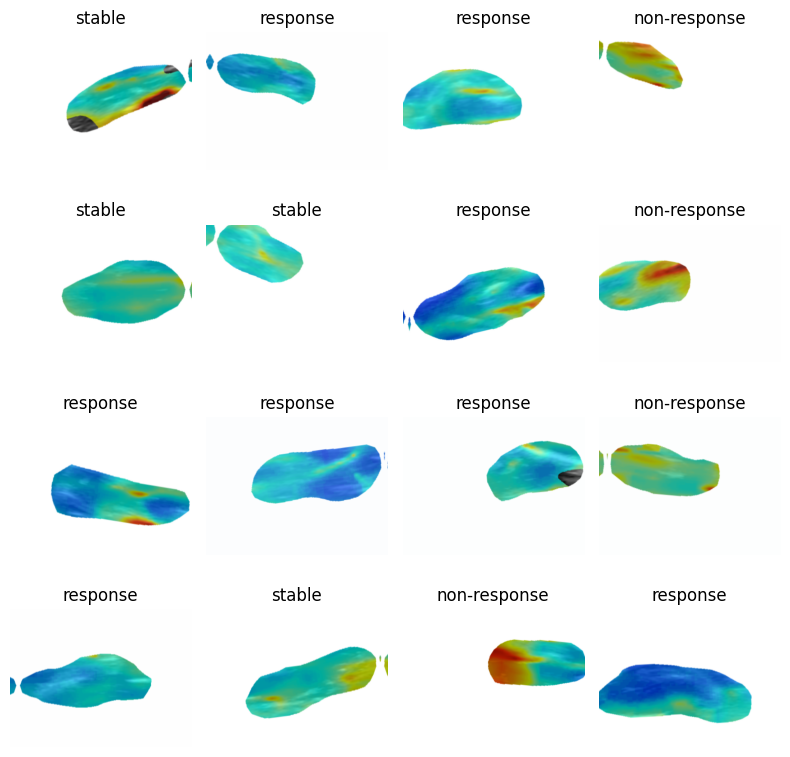

In [34]:
# visualize one batch from tf.data pipeline
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import matplotlib.pyplot as plt

# Take one augmented batch from train_set
for (img_batch, num_batch), label_batch in train_set.take(1):
    imgs = img_batch.numpy()   # shape (B, 304, 400, 3), floats in [0,1]
    labs = label_batch.numpy()
    break

# Plot a grid (up to 4x4 but not more than batch size)
grid_size = 4
n = min(grid_size**2, imgs.shape[0])

plt.figure(figsize=(8, 8))
for i in range(n):
    plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(imgs[i])
    plt.title(class_names[int(labs[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()

# CNN model - TRANSFORMER (MM Model - ViT-16 inspired) 

1) Inputs come in
Image shaped (IMG_HEIGHT, IMG_WIDTH, 3).
Numeric feature(s) shaped (num_num_feats,) (currently 1).

2) Patchify the image (ViT-style)
A Conv2D with kernel_size=stride=patch_size embeds each patch_size × patch_size tile into a projection_dim = transformer_heads * transformer_head_size vector.
Output is a grid (H_patches, W_patches, projection_dim) which is reshaped to tokens (num_patches, projection_dim).
We name this patch_tokens for explainability later.

3) Turn numeric feature into a token
Dense(projection_dim, activation='relu') → num_proj.
Reshape to (1, projection_dim) → num_token.
Now we have a mixed sequence: [num_token] + [patch_tokens...] → shape (1 + num_patches, projection_dim) per sample.

4) Tell the model where each token came from
Positional embeddings via Embedding(seq_len, projection_dim).
Add to the token sequence so the transformer knows patch order/position.

5) Transformer encoder stack
For each layer (use transformer_layers=2):
Pre-norm → MultiHeadAttention (self-attention over the whole sequence) → residual add.
Pre-norm → Dense(ff_dim, relu) → Dropout → Dense(projection_dim) → residual add.
This lets the numeric token attend to image patches and vice-versa.

6) Classification head
Grab the first token (index 0 = the numeric token after mixing) with a Lambda.
LayerNorm → Dense(128, relu) (named cls_embedding for t-SNE/UMAP) → Dropout → final Dense(num_classes, softmax) → predictions.

7) Training setup
Optimizer: SGD with momentum + Nesterov (lr=1e-3).
Schedule: epoch-wise CosineDecay applied via LearningRateScheduler callback.
Loss: SparseCategoricalCrossentropy (labels are integer class ids).
Metrics: accuracy.

8) Callbacks for stability & convenience
EarlyStopping on val_loss with patience 20, restoring best weights.
ModelCheckpoint saving the best full model to best_model.keras.

9) Device guard
Picks /GPU:0 when available, else CPU, so .fit() won’t crash if no GPU.

10) Explainability hooks you added (tiny but powerful)
patch_tokens: recover the patch grid to build attention/rollout or saliency heatmaps.
cls_embedding: a compact 128-D representation you can export and visualize with t-SNE/UMAP.

In [35]:
# Model definition (polished ViT-16 + numeric token) 
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate=0.1):
    # === Your original encoder (ReLU; residual proj back to inputs dim) ===
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout_rate)(x, x)
    x = layers.Dropout(dropout_rate)(x)
    res = layers.Add()([inputs, x])

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return layers.Add()([res, x])

def build_multi_modal_transformer(
    img_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_num_feats=1,
    num_classes=3,
    weight_decay=1e-4,
    dropout_rate=0.1,
    transformer_heads=4,
    transformer_head_size=32,
    transformer_ff_dim=128,
    transformer_layers=2,
    patch_size=16,  # If using 300x400, consider patch_size=10
):
    image_input = Input(shape=img_shape, name='image_input')
    num_input   = Input(shape=(num_num_feats,), name='num_input')

    # ViT-style patch embedding via Conv(stride=patch)
    projection_dim = transformer_head_size * transformer_heads
    x = layers.Conv2D(
        filters=projection_dim,
        kernel_size=(patch_size, patch_size),
        strides=(patch_size, patch_size),
        padding='valid',
        kernel_regularizer=regularizers.l2(weight_decay),
        name="patch_proj"
    )(image_input)

    # Flatten to (batch, num_patches, projection_dim)
    # (use conv output spatial dims for safety)
    patch_h = x.shape[1]
    patch_w = x.shape[2]
    num_patches = patch_h * patch_w
    patch_tokens = layers.Reshape((num_patches, projection_dim), name="patch_tokens")(x)  # ← named for heatmaps

    # Numeric feature → token (as in your original)
    num_proj  = layers.Dense(
        projection_dim, activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay),
        name="num_proj"
    )(num_input)
    num_token = layers.Reshape((1, projection_dim), name="num_token")(num_proj)

    # Sequence: [num_token] + [patch_tokens...]
    x = layers.Concatenate(axis=1, name="token_concat")([num_token, patch_tokens])

    # Positional embeddings (batch-safe positions; minor safety tweak)
    seq_len   = 1 + num_patches
    pos_emb   = layers.Embedding(input_dim=seq_len, output_dim=projection_dim, name="pos_embedding")
    positions = tf.range(start=0, limit=seq_len, delta=1)[tf.newaxis, :]  # (1, L)
    x = layers.Add(name="add_pos")([x, pos_emb(positions)])

    # Transformer stack (unchanged)
    for _ in range(transformer_layers):
        x = transformer_encoder(
            x,
            head_size=transformer_head_size,
            num_heads=transformer_heads,
            ff_dim=transformer_ff_dim,
            dropout_rate=dropout_rate
        )

    # Classification head (numeric token at index 0) — unchanged
    cls = layers.Lambda(lambda z: z[:, 0, :], name="cls_pick")(x)
    cls = layers.LayerNormalization(epsilon=1e-6, name="cls_norm")(cls)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(weight_decay),
                     name="cls_embedding")(cls)   # ← named for t-SNE/UMAP
    x = layers.Dropout(dropout_rate, name="cls_dropout")(x)
    out = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(weight_decay),
                       name='predictions')(x)

    return Model([image_input, num_input], out, name='multi_modal_transformer')

class_names = ["response", "stable", "non-response"]

In [36]:
# ──────────── CHUNK 2: Compile & Train (original cosine-by-epoch + SGD) ────────────
import tensorflow as tf
from tensorflow.keras import optimizers, callbacks

epochs = 100

# Epoch-wise cosine decay (as in your original)
cosine_decay = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=epochs
)

sgd = optimizers.SGD(
    learning_rate=1e-3,
    momentum=0.9,
    nesterov=True
)

def lr_scheduler(epoch, lr):
    return float(cosine_decay(epoch))

lr_scheduler_callback = callbacks.LearningRateScheduler(
    schedule=lr_scheduler,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    start_from_epoch=20,
    verbose=1
)

ckpt = callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Build & compile (unchanged)
model = build_multi_modal_transformer(
    img_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_num_feats=1,
    num_classes=len(class_names),
    weight_decay=1e-4,
    dropout_rate=0.1,
    transformer_heads=4,
    transformer_head_size=32,
    transformer_ff_dim=128,
    transformer_layers=2,
    patch_size=16   # If IMG is 300x400, set patch_size=10
)

model.compile(
    optimizer=sgd,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train (guard device)
device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
with tf.device(device):
    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=epochs,
        callbacks=[lr_scheduler_callback, early_stop, ckpt],
        verbose=2
    )


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/100


2025-10-05 14:33:17.170699: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-10-05 14:33:18.812296: I external/local_xla/xla/service/service.cc:168] XLA service 0x71407c93b4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-05 14:33:18.812336: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
I0000 00:00:1759674798.891532    1244 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 0.53634, saving model to best_model.keras
35/35 - 9s - loss: 0.7905 - accuracy: 0.6404 - val_loss: 0.5363 - val_accuracy: 0.8017 - lr: 0.0010 - 9s/epoch - 260ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.0009997532470151782.
Epoch 2/100

Epoch 2: val_loss did not improve from 0.53634
35/35 - 3s - loss: 0.6099 - accuracy: 0.7409 - val_loss: 0.5646 - val_accuracy: 0.7722 - lr: 9.9975e-04 - 3s/epoch - 81ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 3/100

Epoch 3: val_loss did not improve from 0.53634
35/35 - 3s - loss: 0.6002 - accuracy: 0.7409 - val_loss: 0.5648 - val_accuracy: 0.7806 - lr: 9.9901e-04 - 3s/epoch - 77ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.000997781055048108.
Epoch 4/100

Epoch 4: val_loss improved from 0.53634 to 0.48591, saving model to best_model.keras
35/35 - 3s - loss: 0.5468 - accuracy: 0.7935 - val_loss: 0.4859 - val_accuracy: 0.81

In [37]:
# Using the tf.data pipeline (applies preprocess, batching, prefetch)
test_loss, test_acc = model.evaluate(
    test_set,
    verbose=1
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predict on pipeline
y_test_prob = model.predict(
    test_set,
    verbose=1
)
# Since test_set yields ((images, numerics), labels), you'll need to strip off the labels:
# If batch_size divides your test size exactly, you can do:
y_test_pred = np.argmax(y_test_prob, axis=1)
# And you still have y_test for the true labels.

8/8 [==============================] - 0s 29ms/step - loss: 0.1958 - accuracy: 0.9409
Test loss: 0.1958
Test accuracy: 0.9409
8/8 [==============================] - 0s 17ms/step


In [38]:
# Build a dataset exactly like `train_set` but with augment_data=False:
clean_train_set = make_dataset(
    X_img_train, X_num_train, y_train,
    shuffle=False,
    augment_data=False
)

train_loss_clean, train_acc_clean = model.evaluate(clean_train_set, verbose=1)
print(f"Clean train accuracy: {train_acc_clean:.4f}")

35/35 [==============================] - 1s 12ms/step - loss: 0.1946 - accuracy: 0.9275
Clean train accuracy: 0.9275


In [39]:
# If you saved History, get the index of best val_loss epoch:
best_epoch = int(np.argmin(history.history["val_loss"]))
print("Best epoch (val_loss):", best_epoch)
print("val_acc at best epoch:", history.history["val_accuracy"][best_epoch])

Best epoch (val_loss): 70
val_acc at best epoch: 0.9367088675498962


In [40]:
# Save the model's training history (stored in the history.history dictionary) as a NumPy (.npy) file.
np.save('multi_modal_with_transformer_ViT16.npy', history.history)

In [41]:
# Load the saved training history (a dictionary stored in a NumPy file) with pickling enabled.
df = np.load('multi_modal_with_transformer_ViT16.npy', allow_pickle=True)

# Convert the loaded dictionary (accessed via .item()) into a pandas DataFrame.
# We extract selected keys: 'lr', 'loss', 'accuracy', 'val_loss', and 'val_accuracy',
# which represent the learning rate, training loss, training accuracy, validation loss,
# and validation accuracy collected during training.
df1 = pd.DataFrame({
    'lr': df.item()['lr'],
    'loss': df.item()['loss'],
    'accuracy': df.item()['accuracy'],
    'val_loss': df.item()['val_loss'],
    'val_accuracy': df.item()['val_accuracy']
})

# Print the last few entries of the DataFrame to inspect the training metrics at the end of training.
print(df1.tail())

          lr      loss  accuracy  val_loss  val_accuracy
86  0.000048  0.205775  0.922101  0.236282      0.940928
87  0.000041  0.200244  0.926630  0.235714      0.940928
88  0.000035  0.215066  0.922101  0.234605      0.940928
89  0.000030  0.200453  0.925725  0.241058      0.945148
90  0.000024  0.214552  0.918478  0.236995      0.940928


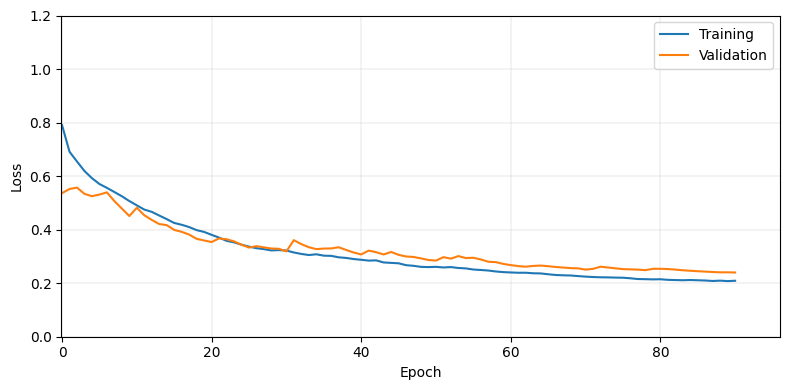

In [42]:
import matplotlib.pyplot as plt

# — your existing plotting code —
plt.figure(figsize=(8,4))
ax = df1['loss'].ewm(span=10).mean().plot(label='Training')
ax = df1['val_loss'].ewm(span=10).mean().plot(label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.grid(linewidth=0.2)
plt.ylim([0, 1.2])
plt.xlim([-0.1, 96])
plt.legend(loc='upper right')

# — save to PDF —
plt.tight_layout()  # make sure labels fit
plt.savefig('training_validation_loss.pdf', format='pdf')

# (optional) display on screen
plt.show()

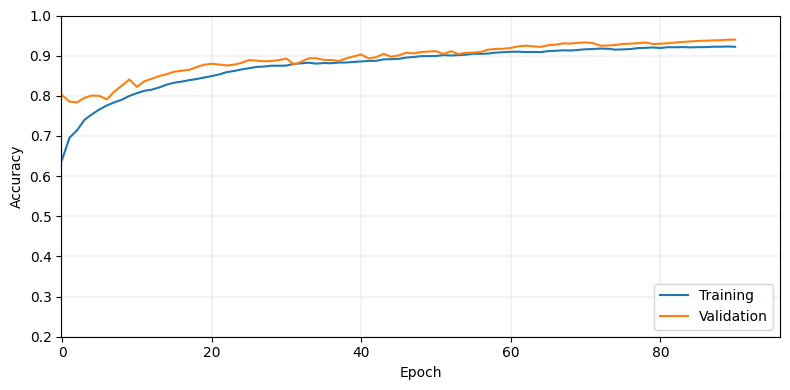

In [43]:
import matplotlib.pyplot as plt

# Create a new figure for plotting training and validation accuracy over epochs.
plt.figure(figsize=(8,4))
ax = df1['accuracy'].ewm(span=10).mean().plot(label='Training')
ax = df1['val_accuracy'].ewm(span=10).mean().plot(label='Validation')

# Set axis labels for clarity.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
plt.grid(linewidth=0.2)
plt.ylim([0.2, 1])
plt.xlim([-0.1, 96])
plt.legend(loc='lower right')

# Ensure layout fits, then save as PDF
plt.tight_layout()
plt.savefig('training_validation_accuracy.pdf', format='pdf')

# (Optional) display it
plt.show()

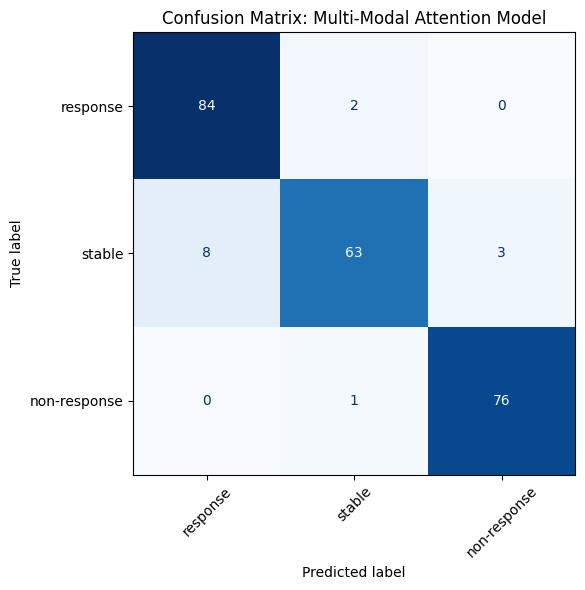

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute the confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)

# Create and plot the ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf_matrix,
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d'  # integer formatting in the cells
)
plt.title("Confusion Matrix: Multi-Modal Attention Model")
plt.xticks(rotation=45)

# — ensure layout and save to PDF —
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', format='pdf')

# (optional) display it
plt.show()

In [45]:
from sklearn.metrics import classification_report

# if you used y_test directly to build test_set (shuffle=False), it's fine:
print(classification_report(
    y_test,
    y_test_pred,    # your argmax’d predictions
    target_names=['Response','Stable','Non-Response']
))

              precision    recall  f1-score   support

    Response       0.91      0.98      0.94        86
      Stable       0.95      0.85      0.90        74
Non-Response       0.96      0.99      0.97        77

    accuracy                           0.94       237
   macro avg       0.94      0.94      0.94       237
weighted avg       0.94      0.94      0.94       237



In [46]:
# Extract true labels from test_set
y_test_true = np.concatenate([
    labels.numpy().astype(int)
    for (_, _), labels in test_set
], axis=0)

# Sanity-check a few examples
for i in range(5):
    print(
        f"Sample {i}: True={class_names[y_test_true[i]]}, "
        f"Pred={class_names[y_test_pred[i]]}, "
        f"Probs={y_test_prob[i]}"
    )

Sample 0: True=non-response, Pred=non-response, Probs=[5.0375820e-06 1.8454486e-04 9.9981040e-01]
Sample 1: True=response, Pred=response, Probs=[9.9872178e-01 1.2579908e-03 2.0264657e-05]
Sample 2: True=stable, Pred=stable, Probs=[0.00613211 0.96372044 0.03014754]
Sample 3: True=response, Pred=response, Probs=[9.9065924e-01 9.2765335e-03 6.4230408e-05]
Sample 4: True=stable, Pred=stable, Probs=[0.00868068 0.98338425 0.00793502]


In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import roc_curve, auc, classification_report
import numpy as np
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

    response       0.91      0.98      0.94        86
      stable       0.95      0.85      0.90        74
non-response       0.96      0.99      0.97        77

    accuracy                           0.94       237
   macro avg       0.94      0.94      0.94       237
weighted avg       0.94      0.94      0.94       237



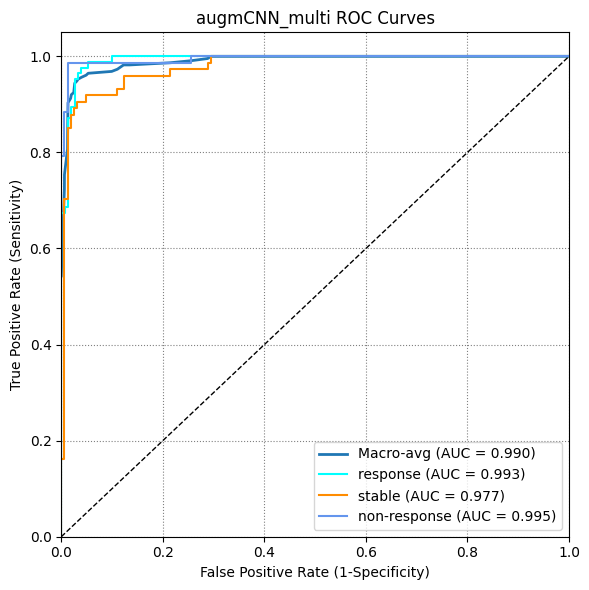

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report

# Classification Report
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names
))

# 2) ROC Curves & AUC
y_true_bin = label_binarize(y_test_true, classes=[0,1,2])
n_classes  = y_true_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# macro‐average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i])
                    for i in range(n_classes)], axis=0)
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# 3) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-avg (AUC = {roc_auc['macro']:.3f})", lw=2)

colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim(0,1); plt.ylim(0,1.05)
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('augmCNN_multi ROC Curves')
plt.legend(loc='lower right')
plt.grid(linestyle=':', color='grey')

# — ensure everything fits, then save to PDF —
plt.tight_layout()
plt.savefig('roc_curve.pdf', format='pdf')

plt.show()

In [49]:
# After you’ve computed fpr, tpr and roc_auc, dump them to disk:
import numpy as np

np.savez(
    "roc_data_transformer_ViT-16.npz",
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc
)

In [50]:
import numpy as np
# Run model.predict on test_set to get all probability scores
y_score = model.predict(test_set, verbose=1)   # shape (N, 3)

# Build y_pred by argmax
y_pred = np.argmax(y_score, axis=1)

# Extract y_true from the labels in test_set
y_true_list = []
for (_, _), label_batch in test_set:
    y_true_list.append(label_batch.numpy())
y_true = np.concatenate(y_true_list)            # shape (N,)

# Now class_names = ["response","stable","non-response"]

8/8 [==============================] - 0s 17ms/step


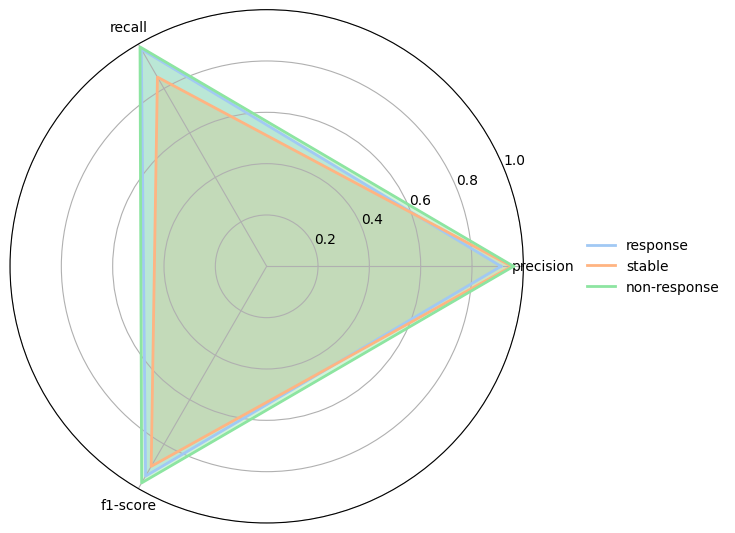

In [51]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1) Compute metrics dict
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

metrics = ['precision','recall','f1-score']
# angle for each metric
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]   # close the circle

pastel_colors = ['#a1c9f4','#ffb482','#8de5a1']

fig, ax = plt.subplots(figsize=(7,6), subplot_kw=dict(polar=True))

for i, label in enumerate(class_names):
    vals = [report[label][m] for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=pastel_colors[i], linewidth=2, label=label)
    ax.fill(angles, vals, color=pastel_colors[i], alpha=0.4)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)
ax.legend(loc='center left', bbox_to_anchor=(1.1,0.5), frameon=False)

plt.tight_layout()
plt.savefig("radar_metrics_filled.pdf", bbox_inches='tight')
plt.show()

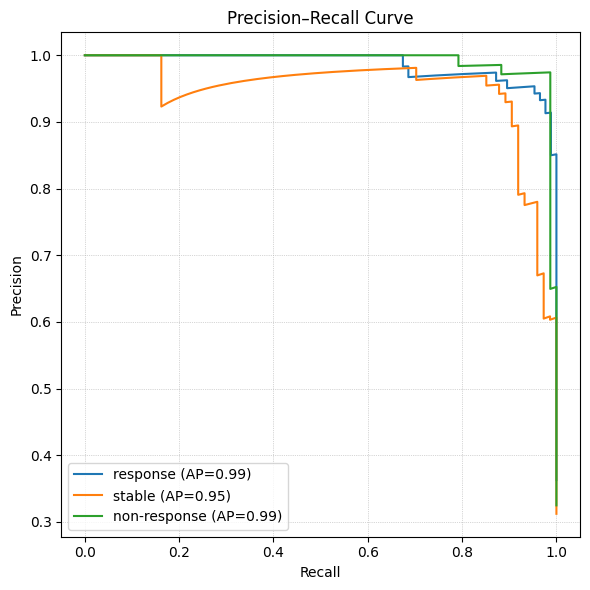

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize the true labels for multiclass PR curves
y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(6,6))
for i, cname in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
    plt.plot(rec, prec, label=f"{cname} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc='best')
plt.grid(linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.savefig("precision_recall_curve.pdf", bbox_inches='tight')
plt.show()

In [53]:
!pip install umap-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 74.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 211.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 145.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 98.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstal

In [54]:
# ───────── t-SNE on the 128-D cls_embedding (clean version) ─────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

# 1) Feature extractor from the named layer we added
feat_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("cls_embedding").output   # (None, 128)
)

# 2) Compute features for the whole test set (order preserved)
features = feat_extractor.predict(test_set, verbose=1)  # shape (N, 128)

# 3) Collect y_true from test_set (same as you did before)
y_true_list = []
for (_, _), label_batch in test_set:
    y_true_list.append(label_batch.numpy())
y_true = np.concatenate(y_true_list).astype(int)        # shape (N,)

# 4) Choose a safe perplexity based on N (t-SNE requires perplexity < N)
N = features.shape[0]
perplexity = max(5, min(30, N // 100 if N >= 500 else 20))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    random_state=42,
    init='pca'
)
X_tsne = tsne.fit_transform(features)  # shape (N,2)

# 5) Plot (matplotlib only; simple, readable)
plt.figure(figsize=(8,6))
for ci, cname in enumerate(class_names):
    idx = (y_true == ci)
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=30, alpha=0.8, label=cname)

plt.title(f"t-SNE of cls_embedding (perplexity={perplexity}, N={N})")
plt.xlabel("t-SNE Dim 1"); plt.ylabel("t-SNE Dim 2")
plt.grid(True, linewidth=0.2)
plt.legend(loc='best', frameon=False)
plt.tight_layout()
plt.savefig("tsne_projection.pdf", bbox_inches='tight')
plt.show()

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py)

In [55]:
pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_636/4113189687.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap(cmap)


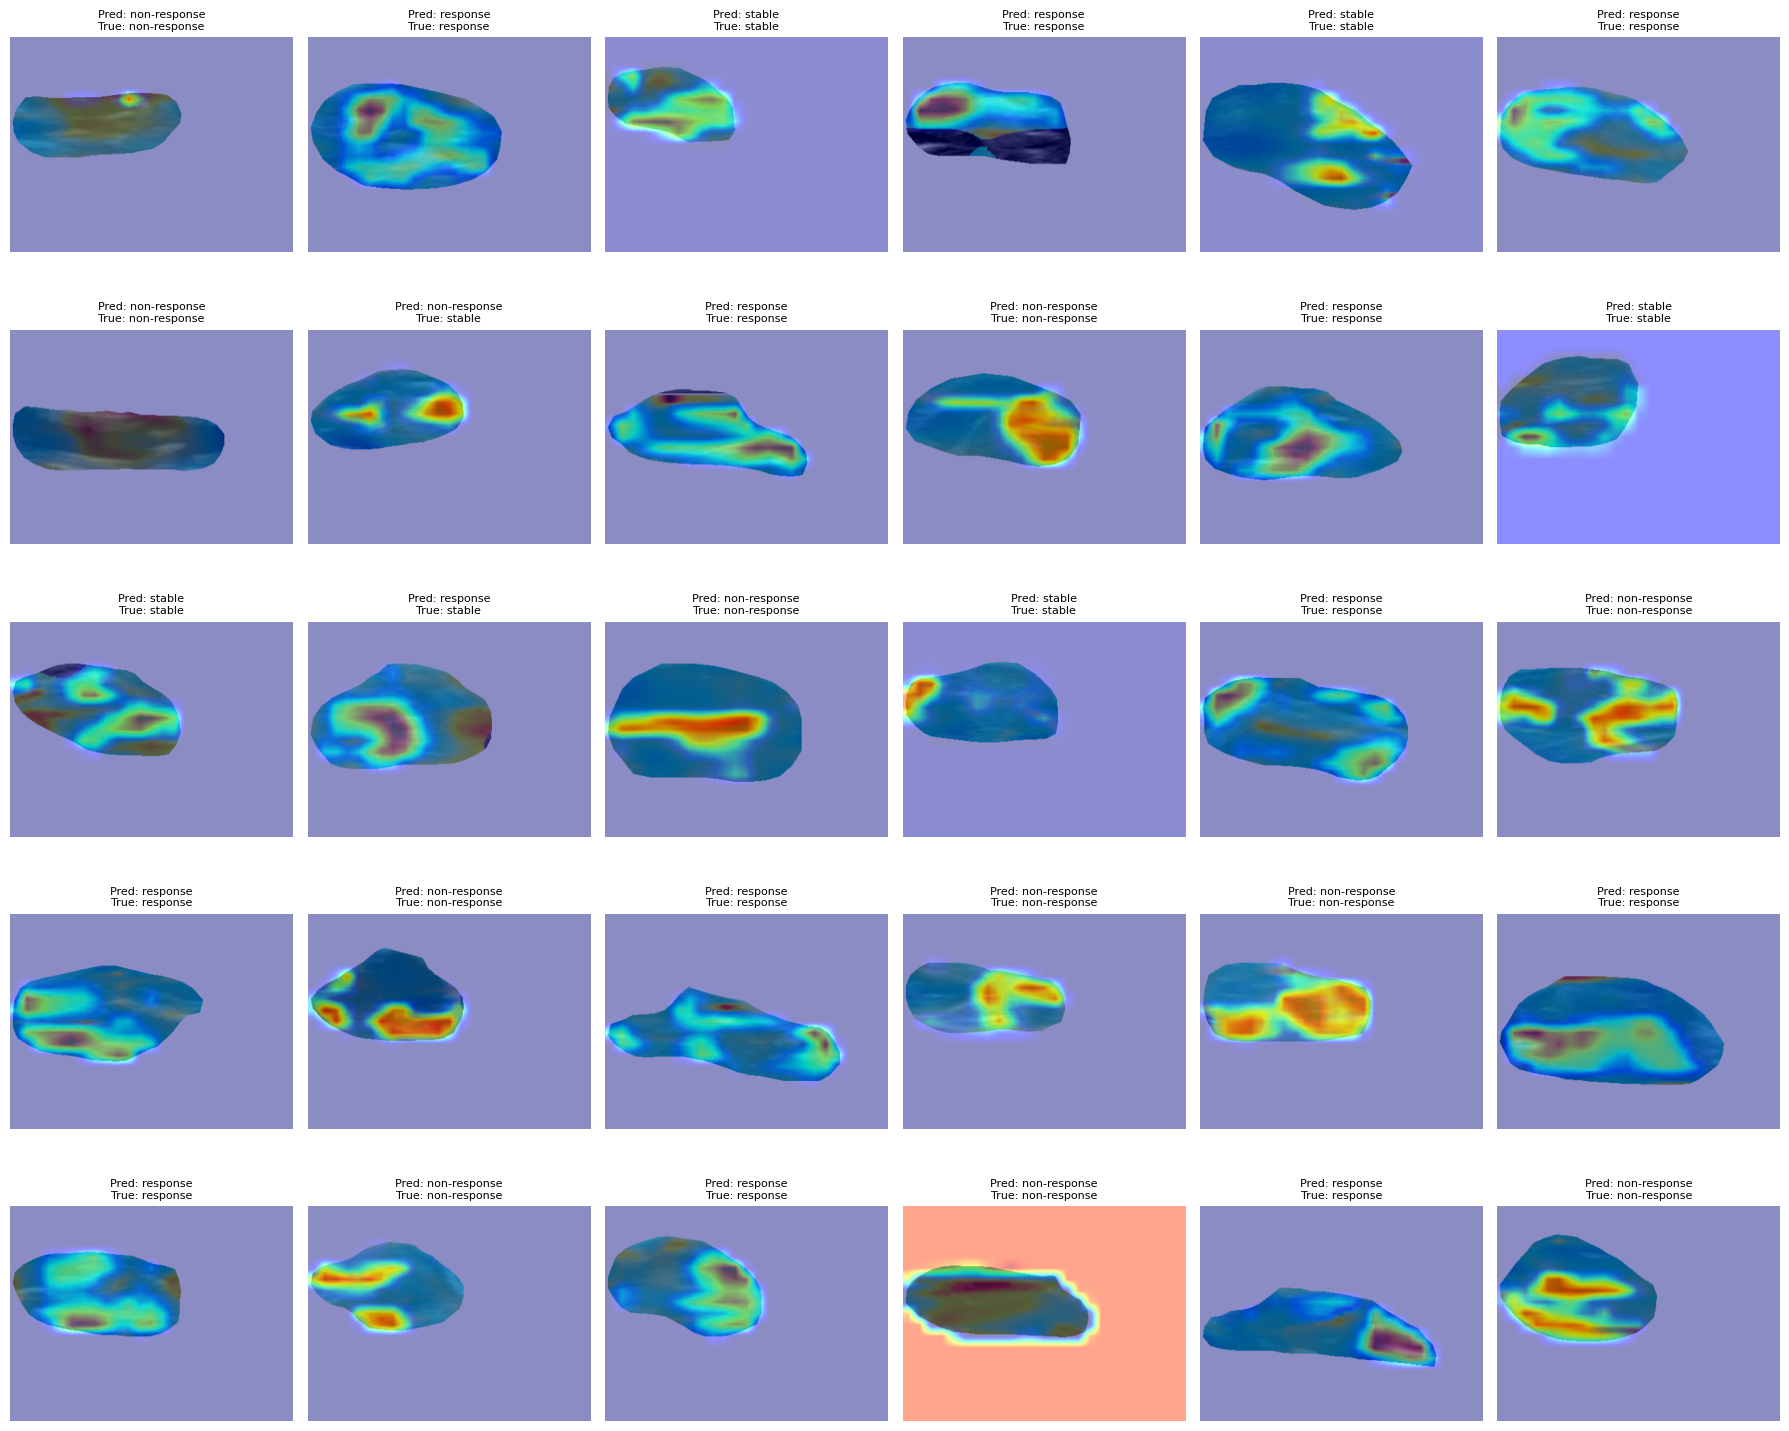

In [56]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------- Core Grad-CAM helper ----------
def make_gradcam_heatmap(model, images, numerics, class_indices=None, layer_name="patch_proj"):
    """
    images:   float32 tensor/ndarray, shape (B,H,W,3), preprocessed to [0,1]
    numerics: float32 tensor/ndarray, shape (B, num_num_feats)
    class_indices: optional list/ndarray of length B with target class ids.
                   If None, uses model's argmax prediction per sample.
    Returns: heatmaps in [0,1], shape (B, H, W)
    """
    # Build a model that returns both the conv feature maps and the final predictions
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]  # (B, h, w, C), (B, num_classes)
    )

    images = tf.convert_to_tensor(images, dtype=tf.float32)
    numerics = tf.convert_to_tensor(numerics, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([images, numerics], training=False)
        if class_indices is None:
            class_indices = tf.argmax(preds, axis=-1)
        else:
            class_indices = tf.convert_to_tensor(class_indices, dtype=tf.int32)
        # Gather the score for each sample's chosen class
        # preds has shape (B, num_classes)
        indices = tf.stack([tf.range(tf.shape(preds)[0]), class_indices], axis=1)
        class_scores = tf.gather_nd(preds, indices)  # shape (B,)

    # Watch conv_out for gradients
    grads = tape.gradient(class_scores, conv_out)  # (B, h, w, C)

    # Global-average-pool the gradients over spatial dims -> weights per channel
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)  # (B,1,1,C)

    # Weighted sum of conv maps across channels
    cam = tf.reduce_sum(weights * conv_out, axis=-1)  # (B, h, w)

    # ReLU and normalize per-sample to [0,1]
    cam = tf.nn.relu(cam)
    # Avoid div-by-zero by adding small epsilon
    cam -= tf.reduce_min(cam, axis=(1,2), keepdims=True)
    cam /= (tf.reduce_max(cam, axis=(1,2), keepdims=True) + 1e-8)

    # Upsample to input image size
    cam_up = tf.image.resize(cam[..., tf.newaxis], size=(images.shape[1], images.shape[2]), method="bilinear")
    return tf.squeeze(cam_up, axis=-1).numpy()  # (B, H, W)

# ---------- Convenience: overlay ----------
def overlay_heatmap_on_image(img, heatmap, alpha=0.4, cmap="jet"):
    """
    img:     (H,W,3) in [0,1]
    heatmap: (H,W) in [0,1]
    returns an RGB float image (H,W,3) in [0,1]
    """
    import matplotlib.cm as cm
    color_map = cm.get_cmap(cmap)
    colored_hm = color_map(heatmap)[:, :, :3]   # drop alpha
    overlay = (1 - alpha) * img + alpha * colored_hm
    overlay = np.clip(overlay, 0.0, 1.0)
    return overlay

# ---------- Run on a batch from test_set ----------
# Grab one batch
for (img_batch, num_batch), label_batch in test_set.take(1):
    imgs = img_batch.numpy()   # already resized and scaled to [0,1] by your pipeline
    nums = num_batch.numpy()
    labels = label_batch.numpy().astype(int)
    break

# Optional: choose target classes (here: use predicted class per image)
preds = model.predict(test_set.take(1), verbose=0)[0:imgs.shape[0]]  # match batch size
target_classes = np.argmax(preds, axis=1)

# Compute heatmaps
heatmaps = make_gradcam_heatmap(model, imgs, nums, class_indices=target_classes, layer_name="patch_proj")

# Visualize up to 30 images
n_show = min(30, imgs.shape[0])
cols = 6  # you can adjust columns to taste
rows = int(np.ceil(n_show / cols))

plt.figure(figsize=(cols * 3, rows * 3))  # scale figure size to fit more images
for i in range(n_show):
    hm = heatmaps[i]
    overlay = overlay_heatmap_on_image(imgs[i], hm, alpha=0.45, cmap="jet")
    plt.subplot(rows, cols, i+1)
    plt.imshow(overlay)
    title = f"Pred: {class_names[target_classes[i]]}\nTrue: {class_names[labels[i]]}"
    plt.title(title, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("gradcam_vit_patchproj_30examples.pdf", bbox_inches="tight")
plt.show()

In [58]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
import seaborn as sns

In [ ]:
# ──────────── SIMPLE EXPLAINER: Grad-CAM (+ optional occlusion) ────────────
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt

os.makedirs("explanations", exist_ok=True)

def make_gradcam_heatmap(model, images, numerics, class_indices=None, layer_name="patch_proj"):
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.Model(inputs=model.inputs,
                                outputs=[conv_layer.output, model.output])
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    numerics = tf.convert_to_tensor(numerics, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([images, numerics], training=False)
        if class_indices is None:
            class_indices = tf.argmax(preds, axis=-1)
        else:
            class_indices = tf.convert_to_tensor(class_indices, dtype=tf.int32)
        idx = tf.stack([tf.range(tf.shape(preds)[0]), class_indices], axis=1)
        class_scores = tf.gather_nd(preds, idx)
    grads = tape.gradient(class_scores, conv_out)                      # (B,h,w,C)
    weights = tf.reduce_mean(grads, axis=(1,2), keepdims=True)         # (B,1,1,C)
    cam = tf.reduce_sum(weights * conv_out, axis=-1)                   # (B,h,w)
    cam = tf.nn.relu(cam)
    cam -= tf.reduce_min(cam, axis=(1,2), keepdims=True)
    cam /= (tf.reduce_max(cam, axis=(1,2), keepdims=True) + 1e-8)
    cam = tf.image.resize(cam[..., None], (images.shape[1], images.shape[2]))
    return tf.squeeze(cam, -1).numpy()                                 # (B,H,W)

def overlay_heatmap(img, heatmap, alpha=0.45, cmap="jet"):
    import matplotlib.cm as cm
    hm = cm.get_cmap(cmap)(heatmap)[..., :3]
    out = (1 - alpha) * img + alpha * hm
    return np.clip(out, 0, 1)

def occlusion_map(model, img, num, target_class, patch=40, stride=20):
    # Fast-ish coarse occlusion just for sanity checks
    H, W, _ = img.shape
    heat = np.zeros((H, W), dtype=np.float32)
    base = model.predict([(img[None, ...]).astype(np.float32),
                          (num).astype(np.float32)], verbose=0)[0, target_class]
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            img_occ = img.copy()
            img_occ[y:y+patch, x:x+patch] = img.mean()
            prob = model.predict([img_occ[None, ...].astype(np.float32),
                                  num.astype(np.float32)], verbose=0)[0, target_class]
            heat[y:y+patch, x:x+patch] = max(0.0, base - prob)
    # normalize 0..1
    if heat.max() > 1e-8:
        heat /= heat.max()
    return heat

def explain_batch_with_gradcam(model, dataset, class_names, n_show=30,
                               use_occlusion=False, save_path="explanations/gradcam_grid.pdf"):
    # 1) take one batch
    for (img_b, num_b), y_b in dataset.take(1):
        imgs = img_b.numpy()
        nums = num_b.numpy()
        labels = y_b.numpy().astype(int)
        break
    B = imgs.shape[0]
    n = min(n_show, B)

    # 2) predictions & target classes
    preds = model.predict(dataset.take(1), verbose=0)[:B]
    tgt = np.argmax(preds, axis=1)

    # 3) grad-cam heatmaps for the batch
    heatmaps = make_gradcam_heatmap(model, imgs, nums, class_indices=tgt, layer_name="patch_proj")

    # 4) plot grid
    cols = 6
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*3.0, rows*3.0))
    for i in range(n):
        overlay = overlay_heatmap(imgs[i], heatmaps[i], alpha=0.45, cmap="jet")
        plt.subplot(rows, cols, i+1)
        plt.imshow(overlay)
        title = f"P:{class_names[tgt[i]]} / T:{class_names[labels[i]]}"
        if use_occlusion:
            # compute once per image (slow-ish, so optional)
            occ = occlusion_map(model, imgs[i], nums[i:i+1], tgt[i], patch=40, stride=20)
            # draw small inset bar for occ “energy”
            title += f"\nOcc∑={occ.sum():.2f}"
        plt.title(title, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

# ---- Run it (shows up to 30 from the first test batch) ----
explain_batch_with_gradcam(model, test_set, class_names, n_show=30, use_occlusion=False,
                           save_path="explanations/gradcam_grid_30.pdf")

In [63]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.3.2

Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
  Using cached scikit_learn-1.3.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.calibration import calibration_curve
import pandas as pd
from datetime import datetime

In [69]:
def save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test=None, 
                                filename=None, include_summary_page=True):
    """
    Save comprehensive confidence analysis as a PDF file
    """
    
    # Generate filename if not provided
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"confidence_analysis_{timestamp}.pdf"
    
    print(f"🔍 GENERATING CONFIDENCE ANALYSIS PDF: {filename}")
    print("=" * 60)
    
    # Get predictions and probabilities
    print("Getting model predictions...")
    y_test_prob = model.predict(test_set, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)
    
    # Convert all labels to integers
    y_test_int = np.array(y_test).astype(int)
    y_test_pred_int = np.array(y_test_pred).astype(int)
    
    # Calculate confidence metrics
    max_probs = np.max(y_test_prob, axis=1)
    pred_entropy = -np.sum(y_test_prob * np.log(y_test_prob + 1e-8), axis=1)
    correct_mask = (y_test_pred_int == y_test_int)
    
    # Separate confidence for correct vs incorrect predictions
    correct_conf = max_probs[correct_mask]
    incorrect_conf = max_probs[~correct_mask]
    correct_entropy = pred_entropy[correct_mask]
    incorrect_entropy = pred_entropy[~correct_mask]
    
    # Define confidence thresholds
    high_conf_thresh = 0.9
    low_conf_thresh = 0.7
    high_conf_mask = max_probs >= high_conf_thresh
    low_conf_mask = max_probs <= low_conf_thresh
    medium_conf_mask = (max_probs > low_conf_thresh) & (max_probs < high_conf_thresh)
    
    # Calculate group stats
    conf_groups = ['High (≥0.9)', 'Medium (0.7-0.9)', 'Low (≤0.7)']
    group_masks = [high_conf_mask, medium_conf_mask, low_conf_mask]
    group_accs = []
    group_counts = []
    
    for mask in group_masks:
        if np.sum(mask) > 0:
            group_accs.append(np.mean(correct_mask[mask]))
            group_counts.append(np.sum(mask))
        else:
            group_accs.append(0)
            group_counts.append(0)
    
    print(f"Test Accuracy: {np.mean(correct_mask):.4f}")
    print(f"Average Confidence: {np.mean(max_probs):.4f}")
    print(f"Total Samples: {len(y_test_int)}")
    
    # Create PDF
    with PdfPages(filename) as pdf:
        
        # =====================================
        # PAGE 1: Summary Statistics
        # =====================================
        if include_summary_page:
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size
            ax.axis('off')
            
            # Create comprehensive summary text
            summary_text = f"""
CONFIDENCE & UNCERTAINTY ANALYSIS REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

{'='*60}
EXECUTIVE SUMMARY
{'='*60}

Overall Performance:
• Test Accuracy: {np.mean(correct_mask):.1%}
• Total Test Samples: {len(y_test_int)}
• Classes: {', '.join(class_names)}

Confidence Distribution:
• Mean Confidence: {np.mean(max_probs):.3f}
• Standard Deviation: {np.std(max_probs):.3f}
• Range: {np.min(max_probs):.3f} - {np.max(max_probs):.3f}

Uncertainty Analysis:
• Mean Entropy: {np.mean(pred_entropy):.3f}
• Standard Deviation: {np.std(pred_entropy):.3f}

{'='*60}
CONFIDENCE GROUP BREAKDOWN
{'='*60}

High Confidence (≥90%):
• Samples: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[0]:.1%}

Medium Confidence (70-90%):
• Samples: {np.sum(medium_conf_mask)} ({np.sum(medium_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[1]:.1%}

Low Confidence (≤70%):
• Samples: {np.sum(low_conf_mask)} ({np.sum(low_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[2]:.1%}

{'='*60}
CLASS-WISE PERFORMANCE
{'='*60}
"""
            
            # Add class-wise statistics
            cm = confusion_matrix(y_test_int, y_test_pred_int)
            for i, class_name in enumerate(class_names):
                true_positives = cm[i, i]
                total_actual = np.sum(cm[i, :])
                total_predicted = np.sum(cm[:, i])
                
                if total_actual > 0:
                    recall = true_positives / total_actual
                    precision = true_positives / total_predicted if total_predicted > 0 else 0
                    class_mask = (y_test_int == i)
                    avg_conf = np.mean(max_probs[class_mask]) if np.sum(class_mask) > 0 else 0
                    
                    summary_text += f"""
{class_name}:
• Samples: {total_actual}
• Precision: {precision:.3f}
• Recall: {recall:.3f}
• Avg Confidence: {avg_conf:.3f}
"""
            
            if len(incorrect_conf) > 0:
                summary_text += f"""

{'='*60}
ERROR ANALYSIS
{'='*60}

Confidence Comparison:
• Correct Predictions: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}
• Incorrect Predictions: {np.mean(incorrect_conf):.3f} ± {np.std(incorrect_conf):.3f}
• Difference: {np.mean(correct_conf) - np.mean(incorrect_conf):.3f}

Uncertainty Comparison:
• Correct Predictions: {np.mean(correct_entropy):.3f} ± {np.std(correct_entropy):.3f}
• Incorrect Predictions: {np.mean(incorrect_entropy):.3f} ± {np.std(incorrect_entropy):.3f}
• Difference: {np.mean(incorrect_entropy) - np.mean(correct_entropy):.3f}

Most Problematic Cases:"""
                
                # Add most confident wrong predictions
                if len(incorrect_conf) > 0:
                    incorrect_indices = np.where(~correct_mask)[0]
                    most_confident_wrong = incorrect_indices[np.argsort(max_probs[incorrect_indices])[-min(5, len(incorrect_indices)):]]
                    for idx in most_confident_wrong:
                        pred_class_idx = int(y_test_pred_int[idx])
                        true_class_idx = int(y_test_int[idx])
                        summary_text += f"""
• Sample {idx}: {max_probs[idx]:.3f} confidence
  Predicted: {class_names[pred_class_idx]}
  Actual: {class_names[true_class_idx]}"""
            else:
                summary_text += f"""

{'='*60}
PERFECT PERFORMANCE!
{'='*60}

🎉 Your model achieved 100% accuracy on the test set!
No incorrect predictions to analyze.
"""
            
            summary_text += f"""

{'='*60}
CLINICAL RECOMMENDATIONS
{'='*60}

Based on this analysis:

1. High Confidence Predictions (≥90%):
   • {np.sum(high_conf_mask)} samples with {group_accs[0]:.1%} accuracy
   • Recommendation: Safe for automated processing

2. Medium Confidence Predictions (70-90%):
   • {np.sum(medium_conf_mask)} samples with {group_accs[1]:.1%} accuracy
   • Recommendation: Consider for automated processing with review

3. Low Confidence Predictions (≤70%):
   • {np.sum(low_conf_mask)} samples with {group_accs[2]:.1%} accuracy
   • Recommendation: Require human expert review

Model Calibration:
• Check calibration plot on next page
• Well-calibrated models have confidence ≈ accuracy

Next Steps:
• Review detailed visualizations in following pages
• Consider threshold optimization for clinical deployment
• Validate on external datasets before clinical use
"""
            
            ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top', fontfamily='monospace',
                   wrap=True)
            
            plt.title('Multi-Modal Transformer Confidence Analysis Report', 
                     fontsize=16, fontweight='bold', pad=20)
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()
        
        # =====================================
        # PAGE 2: Core Confidence Metrics
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))  # Landscape
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confidence Distribution
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.hist(correct_conf, bins=20, alpha=0.7, color='green', 
                label=f'Correct (n={len(correct_conf)})', density=True)
        if len(incorrect_conf) > 0:
            ax1.hist(incorrect_conf, bins=20, alpha=0.7, color='red', 
                    label=f'Incorrect (n={len(incorrect_conf)})', density=True)
            ax1.axvline(np.mean(incorrect_conf), color='red', linestyle='--', alpha=0.8)
        ax1.axvline(np.mean(correct_conf), color='green', linestyle='--', alpha=0.8)
        ax1.set_xlabel('Prediction Confidence')
        ax1.set_ylabel('Density')
        ax1.set_title('Confidence Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Entropy Distribution
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.hist(correct_entropy, bins=20, alpha=0.7, color='green', label='Correct', density=True)
        if len(incorrect_entropy) > 0:
            ax2.hist(incorrect_entropy, bins=20, alpha=0.7, color='red', label='Incorrect', density=True)
            ax2.axvline(np.mean(incorrect_entropy), color='red', linestyle='--', alpha=0.8)
        ax2.axvline(np.mean(correct_entropy), color='green', linestyle='--', alpha=0.8)
        ax2.set_xlabel('Prediction Entropy')
        ax2.set_ylabel('Density')
        ax2.set_title('Uncertainty (Entropy) Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Calibration Plot
        ax3 = fig.add_subplot(gs[1, 0])
        conf_bins = np.linspace(0, 1, 11)
        bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
        bin_accuracies = []
        bin_counts = []
        
        for i in range(len(conf_bins) - 1):
            mask = (max_probs >= conf_bins[i]) & (max_probs < conf_bins[i+1])
            if np.sum(mask) > 0:
                bin_acc = np.mean(correct_mask[mask])
                bin_accuracies.append(bin_acc)
                bin_counts.append(np.sum(mask))
            else:
                bin_accuracies.append(0)
                bin_counts.append(0)
        
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect Calibration')
        valid_bins = np.array(bin_counts) > 0
        if np.any(valid_bins):
            ax3.scatter(np.array(bin_centers)[valid_bins], np.array(bin_accuracies)[valid_bins], 
                       s=np.array(bin_counts)[valid_bins]*2, alpha=0.7, color='blue', label='Model Calibration')
        ax3.set_xlabel('Confidence')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('Calibration Plot (Size = Sample Count)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, 1)
        ax3.set_ylim(0, 1)
        
        # Confidence by Class
        ax4 = fig.add_subplot(gs[1, 1])
        conf_by_class = []
        for cls in range(len(class_names)):
            class_mask = (y_test_int == cls)
            class_conf = max_probs[class_mask]
            conf_by_class.append(class_conf)
        
        if any(len(conf) > 0 for conf in conf_by_class):
            bp = ax4.boxplot(conf_by_class, labels=class_names, patch_artist=True)
            colors = ['lightblue', 'lightgreen', 'lightcoral']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
        
        ax4.set_ylabel('Confidence')
        ax4.set_title('Confidence by True Class')
        ax4.grid(True, alpha=0.3)
        
        plt.suptitle('Core Confidence & Uncertainty Metrics', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 3: Performance Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confusion Matrix
        ax1 = fig.add_subplot(gs[0, :])
        cm = confusion_matrix(y_test_int, y_test_pred_int)
        conf_cm = np.zeros_like(cm, dtype=float)
        for true_cls in range(len(class_names)):
            for pred_cls in range(len(class_names)):
                mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
                if np.sum(mask) > 0:
                    conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
        
        im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
        fig.colorbar(im, ax=ax1)
        
        thresh = cm.max() / 2. if cm.max() > 0 else 0.5
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax1.text(j, i - 0.1, f'{cm[i, j]}', 
                        ha='center', va='center', fontsize=12,
                        color='white' if cm[i, j] > thresh else 'black')
                if cm[i, j] > 0:
                    ax1.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                            ha='center', va='center', fontsize=9, color='red')
        
        ax1.set_xticks(range(len(class_names)))
        ax1.set_yticks(range(len(class_names)))
        ax1.set_xticklabels(class_names)
        ax1.set_yticklabels(class_names)
        ax1.set_title('Confusion Matrix with Average Confidence')
        ax1.set_ylabel('True Label')
        ax1.set_xlabel('Predicted Label')
        
        # Confidence Groups
        ax2 = fig.add_subplot(gs[1, 0])
        bars = ax2.bar(conf_groups, group_accs, color=['green', 'orange', 'red'], alpha=0.7)
        for bar, count in zip(bars, group_counts):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'n={count}', ha='center', va='bottom', fontweight='bold')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy by Confidence Level')
        ax2.set_ylim(0, 1.1)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Numeric Feature vs Confidence (if available)
        ax3 = fig.add_subplot(gs[1, 1])
        if X_num_test is not None:
            numeric_values = X_num_test.flatten()
            correct_indices = np.where(correct_mask)[0]
            incorrect_indices = np.where(~correct_mask)[0]
            
            if len(correct_indices) > 0:
                ax3.scatter(numeric_values[correct_indices], max_probs[correct_indices], 
                           color='green', alpha=0.6, label='Correct', s=20)
            if len(incorrect_indices) > 0:
                ax3.scatter(numeric_values[incorrect_indices], max_probs[incorrect_indices], 
                           color='red', alpha=0.8, label='Incorrect', s=20)
            
            ax3.set_xlabel('Standardized Elastic Modulus (kPa)')
            ax3.set_ylabel('Prediction Confidence')
            ax3.set_title('Numeric Feature vs Confidence')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Numeric features not provided', 
                    ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Numeric Feature Analysis')
        
        plt.suptitle('Detailed Performance Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 4: Sample Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
        
        # Probability Distribution
        ax1 = fig.add_subplot(gs[0, :])
        x_pos = np.arange(len(y_test_int))
        bottom = np.zeros(len(y_test_int))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        
        for cls in range(len(class_names)):
            ax1.bar(x_pos, y_test_prob[:, cls], bottom=bottom, 
                   color=colors[cls % len(colors)], alpha=0.7, label=class_names[cls])
            bottom += y_test_prob[:, cls]
        
        incorrect_indices = np.where(~correct_mask)[0]
        for idx in incorrect_indices:
            ax1.axvline(idx, color='red', alpha=0.3, linewidth=0.5)
        
        ax1.set_xlabel('Test Sample Index')
        ax1.set_ylabel('Probability')
        ax1.set_title('Prediction Probabilities (Red lines = Incorrect predictions)')
        ax1.legend()
        ax1.set_xlim(0, len(y_test_int))
        
        # Most Confident Correct
        ax2 = fig.add_subplot(gs[1, 0])
        if np.sum(correct_mask) > 0:
            most_conf_correct = np.where(correct_mask)[0][np.argsort(max_probs[correct_mask])[-min(10, np.sum(correct_mask)):]]
            conf_values = max_probs[most_conf_correct]
            ax2.barh(range(len(most_conf_correct)), conf_values, color='green', alpha=0.7)
            ax2.set_xlabel('Confidence')
            ax2.set_title('Most Confident Correct')
            ax2.set_yticks(range(len(most_conf_correct)))
            ax2.set_yticklabels([f'S{i}' for i in most_conf_correct])
            ax2.grid(True, alpha=0.3, axis='x')
        else:
            ax2.text(0.5, 0.5, 'No correct\npredictions!', ha='center', va='center', 
                    transform=ax2.transAxes, color='red', fontweight='bold')
        
        # Most Confident Incorrect
        ax3 = fig.add_subplot(gs[1, 1])
        if np.sum(~correct_mask) > 0:
            most_conf_incorrect = np.where(~correct_mask)[0][np.argsort(max_probs[~correct_mask])[-min(10, np.sum(~correct_mask)):]]
            conf_values_inc = max_probs[most_conf_incorrect]
            ax3.barh(range(len(most_conf_incorrect)), conf_values_inc, color='red', alpha=0.7)
            ax3.set_xlabel('Confidence')
            ax3.set_title('Most Confident Incorrect')
            ax3.set_yticks(range(len(most_conf_incorrect)))
            ax3.set_yticklabels([f'S{i}' for i in most_conf_incorrect])
            ax3.grid(True, alpha=0.3, axis='x')
        else:
            ax3.text(0.5, 0.5, 'Perfect\nAccuracy!', ha='center', va='center', 
                    transform=ax3.transAxes, color='green', fontweight='bold')
        
        # Least Confident
        ax4 = fig.add_subplot(gs[1, 2])
        least_confident = np.argsort(max_probs)[:min(10, len(max_probs))]
        least_conf_values = max_probs[least_confident]
        colors_least = ['green' if correct_mask[i] else 'red' for i in least_confident]
        ax4.barh(range(len(least_confident)), least_conf_values, color=colors_least, alpha=0.7)
        ax4.set_xlabel('Confidence')
        ax4.set_title('Least Confident')
        ax4.set_yticks(range(len(least_confident)))
        ax4.set_yticklabels([f'S{i}' for i in least_confident])
        ax4.grid(True, alpha=0.3, axis='x')
        
        plt.suptitle('Sample-Level Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        print(f"✅ PDF saved successfully: {filename}")
        print(f"📄 Pages: {4 if include_summary_page else 3}")
        print(f"📊 Analysis complete!")
    
    return {
        'probabilities': y_test_prob,
        'predictions': y_test_pred_int,
        'true_labels': y_test_int,
        'confidences': max_probs,
        'entropies': pred_entropy,
        'correct_mask': correct_mask,
        'filename': filename
    }

# Usage examples:

# Basic usage - saves with timestamp
# results = save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test)

# Custom filename
# results = save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test, 
#                                       filename="my_model_analysis.pdf")

# Skip summary page (just plots)
# results = save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test,
#                                       include_summary_page=False)

In [70]:
# Run the analysis
results = comprehensive_confidence_analysis(
    model=model, 
    test_set=test_set, 
    y_test=y_test, 
    class_names=class_names,
    X_num_test=X_num_test  # Your standardized elastic modulus values
)

NameError: name 'comprehensive_confidence_analysis' is not defined

In [ ]:
# Save with your own filename
results = save_confidence_analysis_pdf(
    model=model, 
    test_set=test_set, 
    y_test=y_test, 
    class_names=class_names,
    X_num_test=X_num_test,
    filename="elastography_model_confidence_analysis.pdf"
)

📊 The 12 Plots Explained Simply:
Row 1: "How confident is my model?"
🎯 Plot 1 - Confidence Distribution:

What it is: Histogram showing how confident your model is in its predictions
Green bars: When model is correct, how confident was it?
Red bars: When model is wrong, how confident was it?
Good sign: Green bars shifted right (high confidence when correct), red bars shifted left (low confidence when wrong)
Real meaning: "Does my model know when it's right vs wrong?"

🌀 Plot 2 - Entropy Distribution:

What it is: Measures uncertainty/confusion in predictions
Low entropy: Model is sure (like 95% class A, 3% class B, 2% class C)
High entropy: Model is confused (like 40% class A, 35% class B, 25% class C)
Good sign: Green (correct) has low entropy, red (incorrect) has high entropy
Real meaning: "Is my model more confused when it makes mistakes?"

📈 Plot 3 - Calibration Plot:

What it is: Checks if "90% confidence" actually means "90% accurate"
Perfect diagonal: If model says 80% confident, it should be right 80% of the time
Above diagonal: Model is under-confident (says 70% but actually right 90% of time)
Below diagonal: Model is over-confident (says 90% but only right 70% of time)
Real meaning: "Can I trust the confidence scores?"

📦 Plot 4 - Confidence by Class:

What it is: Box plots showing confidence for each disease/treatment class
Compares: Is model more confident predicting "response" vs "non-response"?
Clinical insight: Some diseases might be harder to diagnose confidently
Real meaning: "Which conditions does my model struggle with?"

Row 2: "Where does my model make mistakes?"
🔥 Plot 5 - Confusion Matrix with Confidence:

What it is: Classic confusion matrix but with confidence scores added
Numbers: How many predictions in each category
Red text: Average confidence for each type of mistake
Key insight: High confidence on diagonal (correct), low confidence off-diagonal (errors)
Real meaning: "What types of mistakes does my model make and how sure is it?"

📊 Plot 6 - Accuracy by Confidence Level:

What it is: Groups predictions by confidence, shows accuracy for each group
High confidence: Should have very high accuracy (>95%)
Low confidence: Lower accuracy is expected
Clinical use: Set thresholds - maybe auto-approve high confidence, human review low confidence
Real meaning: "What confidence threshold should I use for clinical decisions?"

Row 3: "What does my model see in each case?"
🎨 Plot 7 - Probability Distributions:

What it is: Stacked bar chart showing probability for each class, for every test case
Each bar: One patient/sample, showing model's probability breakdown
Red lines: Mark where model got it wrong
Pattern check: Are wrong predictions near decision boundaries (close to 33% each class)?
Real meaning: "How sure was my model for each individual patient?"

🔢 Plot 8 - Numeric Feature vs Confidence:

What it is: Scatter plot of elastic modulus (kPa) vs how confident model is
Green dots: Correct predictions
Red dots: Incorrect predictions
Medical insight: Are certain stiffness ranges harder to predict?
Real meaning: "Do certain physical measurements make diagnosis more difficult?"

Row 4: "Which cases should I investigate?"
✅ Plot 9 - Most Confident Correct:

What it is: Top 10 cases where model was very confident AND right
These are: Your model's "slam dunk" cases
Clinical value: Examples of clear-cut diagnoses
Real meaning: "What do obvious cases look like?"

❌ Plot 10 - Most Confident Incorrect:

What it is: Cases where model was very confident BUT wrong
These are: Most dangerous cases for clinical use
Critical review: These need human investigation - possible data errors or rare cases
Real meaning: "What cases fool my model badly?"

⚠️ Plot 11 - Least Confident Predictions:

What it is: Cases where model was most uncertain
Green/Red: Which uncertain cases were actually right/wrong
Clinical workflow: These need human expert review
Real meaning: "Which cases are genuinely difficult to diagnose?"

📈 Plot 12 - Summary Statistics:

What it is: Text summary of all the key numbers
Includes: Overall accuracy, confidence ranges, group counts
Reference: Quick lookup for key metrics

🏥 Why This Matters for Medical AI:
Clinical Decision Making:

High confidence correct: Safe for automated processing
High confidence incorrect: Systematic errors that need fixing
Low confidence: Cases needing human expert review

Trust and Reliability:

Calibration: Can you trust the confidence scores?
Uncertainty: Does model know when it doesn't know?
Error patterns: What types of cases are problematic?

Real-World Deployment:

Threshold setting: What confidence level to require?
Workflow integration: When to alert human experts?
Quality assurance: Which predictions to double-check?

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from datetime import datetime
import os

def save_individual_confidence_plots(model, test_set, y_test, class_names, X_num_test=None, 
                                   output_dir=None, prefix=None):
    """
    Save each confidence analysis plot as a separate PDF file
    
    Parameters:
    -----------
    model : trained model
    test_set : test dataset
    y_test : true labels
    class_names : list of class names
    X_num_test : numeric features (optional)
    output_dir : directory to save plots (default: current directory)
    prefix : prefix for filenames (default: timestamp)
    
    Returns:
    --------
    dict : results and list of saved files
    """
    
    # Setup output directory
    if output_dir is None:
        output_dir = "."
    else:
        os.makedirs(output_dir, exist_ok=True)
    
    # Setup filename prefix
    if prefix is None:
        prefix = f"confidence_plot_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    print(f"🔍 SAVING INDIVIDUAL CONFIDENCE PLOTS")
    print(f"📁 Output directory: {output_dir}")
    print(f"📝 Filename prefix: {prefix}")
    print("=" * 60)
    
    # Get predictions and probabilities
    print("Getting model predictions...")
    y_test_prob = model.predict(test_set, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)
    
    # Convert all labels to integers
    y_test_int = np.array(y_test).astype(int)
    y_test_pred_int = np.array(y_test_pred).astype(int)
    
    # Calculate confidence metrics
    max_probs = np.max(y_test_prob, axis=1)
    pred_entropy = -np.sum(y_test_prob * np.log(y_test_prob + 1e-8), axis=1)
    correct_mask = (y_test_pred_int == y_test_int)
    
    # Separate confidence for correct vs incorrect predictions
    correct_conf = max_probs[correct_mask]
    incorrect_conf = max_probs[~correct_mask]
    correct_entropy = pred_entropy[correct_mask]
    incorrect_entropy = pred_entropy[~correct_mask]
    
    # Define confidence thresholds
    high_conf_thresh = 0.9
    low_conf_thresh = 0.7
    high_conf_mask = max_probs >= high_conf_thresh
    low_conf_mask = max_probs <= low_conf_thresh
    medium_conf_mask = (max_probs > low_conf_thresh) & (max_probs < high_conf_thresh)
    
    # Calculate group stats
    conf_groups = ['High\n(≥0.9)', 'Medium\n(0.7-0.9)', 'Low\n(≤0.7)']
    group_masks = [high_conf_mask, medium_conf_mask, low_conf_mask]
    group_accs = []
    group_counts = []
    
    for mask in group_masks:
        if np.sum(mask) > 0:
            group_accs.append(np.mean(correct_mask[mask]))
            group_counts.append(np.sum(mask))
        else:
            group_accs.append(0)
            group_counts.append(0)
    
    saved_files = []
    
    # =====================================
    # PLOT 1: Confidence Distribution
    # =====================================
    print("📊 Saving Plot 1: Confidence Distribution...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(correct_conf, bins=20, alpha=0.7, color='green', 
            label=f'Correct Predictions (n={len(correct_conf)})', density=True)
    if len(incorrect_conf) > 0:
        ax.hist(incorrect_conf, bins=20, alpha=0.7, color='red', 
                label=f'Incorrect Predictions (n={len(incorrect_conf)})', density=True)
        ax.axvline(np.mean(incorrect_conf), color='red', linestyle='--', alpha=0.8, 
                  label=f'Mean Incorrect: {np.mean(incorrect_conf):.3f}')
    ax.axvline(np.mean(correct_conf), color='green', linestyle='--', alpha=0.8,
              label=f'Mean Correct: {np.mean(correct_conf):.3f}')
    
    ax.set_xlabel('Prediction Confidence', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Confidence Distribution: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add summary statistics
    stats_text = f"""Model Performance Summary:
• Total Samples: {len(y_test_int)}
• Accuracy: {np.mean(correct_mask):.1%}
• Mean Confidence: {np.mean(max_probs):.3f}"""
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_01_confidence_distribution.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 2: Entropy Distribution
    # =====================================
    print("📊 Saving Plot 2: Entropy Distribution...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(correct_entropy, bins=20, alpha=0.7, color='green', 
            label=f'Correct Predictions', density=True)
    if len(incorrect_entropy) > 0:
        ax.hist(incorrect_entropy, bins=20, alpha=0.7, color='red', 
                label=f'Incorrect Predictions', density=True)
        ax.axvline(np.mean(incorrect_entropy), color='red', linestyle='--', alpha=0.8,
                  label=f'Mean Incorrect: {np.mean(incorrect_entropy):.3f}')
    ax.axvline(np.mean(correct_entropy), color='green', linestyle='--', alpha=0.8,
              label=f'Mean Correct: {np.mean(correct_entropy):.3f}')
    
    ax.set_xlabel('Prediction Entropy (Uncertainty)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Uncertainty Distribution: Model Entropy Analysis', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add explanation
    explanation = """Entropy Interpretation:
• Low entropy: Model is confident (clear winner)
• High entropy: Model is uncertain (close probabilities)
• Good models: Low entropy when correct, high when incorrect"""
    
    ax.text(0.98, 0.98, explanation, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_02_entropy_distribution.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 3: Calibration Plot
    # =====================================
    print("📊 Saving Plot 3: Calibration Plot...")
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Calculate calibration
    conf_bins = np.linspace(0, 1, 11)
    bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
    bin_accuracies = []
    bin_counts = []
    
    for i in range(len(conf_bins) - 1):
        mask = (max_probs >= conf_bins[i]) & (max_probs < conf_bins[i+1])
        if np.sum(mask) > 0:
            bin_acc = np.mean(correct_mask[mask])
            bin_accuracies.append(bin_acc)
            bin_counts.append(np.sum(mask))
        else:
            bin_accuracies.append(0)
            bin_counts.append(0)
    
    # Plot perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.7, linewidth=2, label='Perfect Calibration')
    
    # Plot actual calibration
    valid_bins = np.array(bin_counts) > 0
    if np.any(valid_bins):
        scatter = ax.scatter(np.array(bin_centers)[valid_bins], np.array(bin_accuracies)[valid_bins], 
                   s=np.array(bin_counts)[valid_bins]*3, alpha=0.7, color='blue', 
                   label='Model Calibration', edgecolors='darkblue')
        
        # Add sample count annotations
        for i, (x, y, count) in enumerate(zip(np.array(bin_centers)[valid_bins], 
                                            np.array(bin_accuracies)[valid_bins],
                                            np.array(bin_counts)[valid_bins])):
            if count > 0:
                ax.annotate(f'n={count}', (x, y), xytext=(5, 5), 
                           textcoords='offset points', fontsize=8, alpha=0.8)
    
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Model Calibration: Confidence vs Actual Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Add interpretation
    interpretation = """Calibration Assessment:
• On diagonal: Well-calibrated
• Above diagonal: Under-confident
• Below diagonal: Over-confident
• Bubble size: Number of samples"""
    
    ax.text(0.02, 0.98, interpretation, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_03_calibration_plot.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 4: Confidence by Class
    # =====================================
    print("📊 Saving Plot 4: Confidence by Class...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    conf_by_class = []
    class_stats = []
    for cls in range(len(class_names)):
        class_mask = (y_test_int == cls)
        class_conf = max_probs[class_mask]
        conf_by_class.append(class_conf)
        class_stats.append({
            'class': class_names[cls],
            'count': np.sum(class_mask),
            'mean_conf': np.mean(class_conf) if len(class_conf) > 0 else 0,
            'std_conf': np.std(class_conf) if len(class_conf) > 0 else 0
        })
    
    if any(len(conf) > 0 for conf in conf_by_class):
        bp = ax.boxplot(conf_by_class, labels=class_names, patch_artist=True)
        colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
        
        # Add mean values as red diamonds
        for i, conf in enumerate(conf_by_class):
            if len(conf) > 0:
                ax.scatter(i+1, np.mean(conf), color='red', marker='D', s=50, zorder=5)
    
    ax.set_ylabel('Prediction Confidence', fontsize=12)
    ax.set_xlabel('True Class', fontsize=12)
    ax.set_title('Confidence Distribution by True Class', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics table
    stats_text = "Class Statistics:\n"
    for stat in class_stats:
        stats_text += f"• {stat['class']}: n={stat['count']}, μ={stat['mean_conf']:.3f}, σ={stat['std_conf']:.3f}\n"
    
    ax.text(0.98, 0.98, stats_text.strip(), transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_04_confidence_by_class.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 5: Confusion Matrix
    # =====================================
    print("📊 Saving Plot 5: Confusion Matrix with Confidence...")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    cm = confusion_matrix(y_test_int, y_test_pred_int)
    conf_cm = np.zeros_like(cm, dtype=float)
    for true_cls in range(len(class_names)):
        for pred_cls in range(len(class_names)):
            mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
            if np.sum(mask) > 0:
                conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Number of Predictions', fontsize=10)
    
    thresh = cm.max() / 2. if cm.max() > 0 else 0.5
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            # Count annotation
            ax.text(j, i - 0.15, f'{cm[i, j]}', 
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if cm[i, j] > thresh else 'black')
            # Confidence annotation
            if cm[i, j] > 0:
                ax.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                        ha='center', va='center', fontsize=9, color='darkred')
    
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_title('Confusion Matrix with Average Confidence', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_05_confusion_matrix.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 6: Accuracy by Confidence Level
    # =====================================
    print("📊 Saving Plot 6: Accuracy by Confidence Level...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(conf_groups, group_accs, color=['green', 'orange', 'red'], alpha=0.7, 
                  edgecolor='black', linewidth=1)
    
    # Add count and accuracy annotations
    for bar, count, acc in zip(bars, group_counts, group_accs):
        height = bar.get_height()
        # Sample count
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={count}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        # Accuracy percentage
        ax.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{acc:.1%}', ha='center', va='center', fontweight='bold', 
                fontsize=12, color='white' if acc > 0.5 else 'black')
    
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('Confidence Level', fontsize=12)
    ax.set_title('Model Accuracy by Confidence Level', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add clinical recommendations
    recommendations = """Clinical Decision Thresholds:
• High Confidence (≥90%): Auto-approve
• Medium Confidence (70-90%): Flag for review
• Low Confidence (≤70%): Require human expert"""
    
    ax.text(0.02, 0.98, recommendations, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_06_accuracy_by_confidence.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 7: Probability Distributions
    # =====================================
    print("📊 Saving Plot 7: Probability Distributions...")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x_pos = np.arange(len(y_test_int))
    bottom = np.zeros(len(y_test_int))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for cls in range(len(class_names)):
        ax.bar(x_pos, y_test_prob[:, cls], bottom=bottom, 
               color=colors[cls % len(colors)], alpha=0.7, label=class_names[cls])
        bottom += y_test_prob[:, cls]
    
    # Highlight incorrect predictions
    incorrect_indices = np.where(~correct_mask)[0]
    for idx in incorrect_indices:
        ax.axvline(idx, color='red', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Test Sample Index', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title('Prediction Probabilities for All Test Samples', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0, len(y_test_int))
    ax.set_ylim(0, 1)
    
    # Add annotation about red lines
    ax.text(0.98, 0.98, f'Red lines mark {len(incorrect_indices)} incorrect predictions', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='pink', alpha=0.8))
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_07_probability_distributions.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 8: Numeric Feature vs Confidence
    # =====================================
    print("📊 Saving Plot 8: Numeric Feature vs Confidence...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    if X_num_test is not None:
        numeric_values = X_num_test.flatten()
        correct_indices = np.where(correct_mask)[0]
        incorrect_indices = np.where(~correct_mask)[0]
        
        if len(correct_indices) > 0:
            ax.scatter(numeric_values[correct_indices], max_probs[correct_indices], 
                       color='green', alpha=0.6, label=f'Correct (n={len(correct_indices)})', s=30)
        if len(incorrect_indices) > 0:
            ax.scatter(numeric_values[incorrect_indices], max_probs[incorrect_indices], 
                       color='red', alpha=0.8, label=f'Incorrect (n={len(incorrect_indices)})', s=30)
        
        ax.set_xlabel('Standardized Elastic Modulus (kPa)', fontsize=12)
        ax.set_ylabel('Prediction Confidence', fontsize=12)
        ax.set_title('Numeric Feature vs Prediction Confidence', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add correlation analysis
        from scipy.stats import pearsonr
        corr_coef, p_value = pearsonr(numeric_values, max_probs)
        stats_text = f"""Correlation Analysis:
• Pearson r: {corr_coef:.3f}
• P-value: {p_value:.3f}
• Significance: {'Yes' if p_value < 0.05 else 'No'}"""
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'Numeric features not provided', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title('Numeric Feature Analysis (Not Available)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_08_numeric_vs_confidence.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # PLOT 9-11: Sample Analysis (Combined)
    # =====================================
    print("📊 Saving Plot 9: Sample Analysis...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Most Confident Correct
    ax = axes[0]
    if np.sum(correct_mask) > 0:
        most_conf_correct = np.where(correct_mask)[0][np.argsort(max_probs[correct_mask])[-min(10, np.sum(correct_mask)):]]
        conf_values = max_probs[most_conf_correct]
        bars = ax.barh(range(len(most_conf_correct)), conf_values, color='green', alpha=0.7)
        ax.set_xlabel('Confidence')
        ax.set_title('Most Confident Correct Predictions')
        ax.set_yticks(range(len(most_conf_correct)))
        ax.set_yticklabels([f'Sample {i}' for i in most_conf_correct])
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add confidence values
        for i, (bar, conf) in enumerate(zip(bars, conf_values)):
            ax.text(conf + 0.01, i, f'{conf:.3f}', va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No correct\npredictions!', ha='center', va='center', 
                transform=ax.transAxes, color='red', fontweight='bold')
        ax.set_title('Most Confident Correct')
    
    # Most Confident Incorrect
    ax = axes[1]
    if np.sum(~correct_mask) > 0:
        most_conf_incorrect = np.where(~correct_mask)[0][np.argsort(max_probs[~correct_mask])[-min(10, np.sum(~correct_mask)):]]
        conf_values_inc = max_probs[most_conf_incorrect]
        bars = ax.barh(range(len(most_conf_incorrect)), conf_values_inc, color='red', alpha=0.7)
        ax.set_xlabel('Confidence')
        ax.set_title('Most Confident Incorrect Predictions')
        ax.set_yticks(range(len(most_conf_incorrect)))
        ax.set_yticklabels([f'Sample {i}' for i in most_conf_incorrect])
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add confidence values and true vs predicted labels
        for i, (bar, conf, idx) in enumerate(zip(bars, conf_values_inc, most_conf_incorrect)):
            ax.text(conf + 0.01, i, f'{conf:.3f}', va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Perfect\nAccuracy!', ha='center', va='center', 
                transform=ax.transAxes, color='green', fontweight='bold')
        ax.set_title('Most Confident Incorrect')
    
    # Least Confident
    ax = axes[2]
    least_confident = np.argsort(max_probs)[:min(10, len(max_probs))]
    least_conf_values = max_probs[least_confident]
    colors_least = ['green' if correct_mask[i] else 'red' for i in least_confident]
    bars = ax.barh(range(len(least_confident)), least_conf_values, color=colors_least, alpha=0.7)
    ax.set_xlabel('Confidence')
    ax.set_title('Least Confident Predictions')
    ax.set_yticks(range(len(least_confident)))
    ax.set_yticklabels([f'Sample {i}' for i in least_confident])
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add confidence values
    for i, (bar, conf) in enumerate(zip(bars, least_conf_values)):
        ax.text(conf + 0.01, i, f'{conf:.3f}', va='center', fontsize=8)
    
    plt.suptitle('Sample-Level Analysis: Edge Cases', fontsize=14, fontweight='bold')
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_09_sample_analysis.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # =====================================
    # Summary Report
    # =====================================
    print("📊 Saving Plot 10: Summary Report...")
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size
    ax.axis('off')
    
    # Create comprehensive summary
    summary_text = f"""
CONFIDENCE ANALYSIS SUMMARY REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

{'='*50}
OVERALL PERFORMANCE
{'='*50}

Test Accuracy: {np.mean(correct_mask):.1%}
Total Test Samples: {len(y_test_int)}
Classes: {', '.join(class_names)}

{'='*50}
CONFIDENCE METRICS
{'='*50}

Overall Statistics:
• Mean Confidence: {np.mean(max_probs):.3f}
• Standard Deviation: {np.std(max_probs):.3f}
• Range: {np.min(max_probs):.3f} - {np.max(max_probs):.3f}

Correct vs Incorrect Predictions:"""
    
    if len(incorrect_conf) > 0:
        summary_text += f"""
• Correct Predictions: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}
• Incorrect Predictions: {np.mean(incorrect_conf):.3f} ± {np.std(incorrect_conf):.3f}
• Confidence Gap: {np.mean(correct_conf) - np.mean(incorrect_conf):.3f}"""
    else:
        summary_text += f"""
• Correct Predictions: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}
• Incorrect Predictions: None (Perfect Accuracy!)"""
    
    summary_text += f"""

{'='*50}
UNCERTAINTY ANALYSIS
{'='*50}

Entropy Statistics:
• Mean Entropy: {np.mean(pred_entropy):.3f}
• Standard Deviation: {np.std(pred_entropy):.3f}

Entropy by Correctness:"""
    
    if len(incorrect_entropy) > 0:
        summary_text += f"""
• Correct Predictions: {np.mean(correct_entropy):.3f} ± {np.std(correct_entropy):.3f}
• Incorrect Predictions: {np.mean(incorrect_entropy):.3f} ± {np.std(incorrect_entropy):.3f}
• Uncertainty Gap: {np.mean(incorrect_entropy) - np.mean(correct_entropy):.3f}"""
    else:
        summary_text += f"""
• Correct Predictions: {np.mean(correct_entropy):.3f} ± {np.std(correct_entropy):.3f}
• Incorrect Predictions: None (Perfect Accuracy!)"""
    
    summary_text += f"""

{'='*50}
CONFIDENCE GROUP ANALYSIS
{'='*50}

High Confidence (≥90%):
• Samples: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[0]:.1%}

Medium Confidence (70-90%):
• Samples: {np.sum(medium_conf_mask)} ({np.sum(medium_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[1]:.1%}

Low Confidence (≤70%):
• Samples: {np.sum(low_conf_mask)} ({np.sum(low_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[2]:.1%}

{'='*50}
CLASS-WISE ANALYSIS
{'='*50}
"""
    
    # Add class-wise statistics
    cm = confusion_matrix(y_test_int, y_test_pred_int)
    for i, class_name in enumerate(class_names):
        true_positives = cm[i, i]
        total_actual = np.sum(cm[i, :])
        total_predicted = np.sum(cm[:, i])
        
        if total_actual > 0:
            recall = true_positives / total_actual
            precision = true_positives / total_predicted if total_predicted > 0 else 0
            class_mask = (y_test_int == i)
            avg_conf = np.mean(max_probs[class_mask]) if np.sum(class_mask) > 0 else 0
            
            summary_text += f"""
{class_name}:
• Samples: {total_actual}
• Precision: {precision:.3f}
• Recall: {recall:.3f}
• Avg Confidence: {avg_conf:.3f}"""
    
    if len(incorrect_conf) > 0:
        summary_text += f"""

{'='*50}
CLINICAL RECOMMENDATIONS
{'='*50}

Based on this confidence analysis:

1. AUTO-APPROVE (High Confidence ≥90%):
   • {np.sum(high_conf_mask)} samples ({group_accs[0]:.1%} accuracy)
   • Safe for automated clinical decisions

2. FLAG FOR REVIEW (Medium Confidence 70-90%):
   • {np.sum(medium_conf_mask)} samples ({group_accs[1]:.1%} accuracy)
   • Consider secondary validation

3. REQUIRE EXPERT REVIEW (Low Confidence ≤70%):
   • {np.sum(low_conf_mask)} samples ({group_accs[2]:.1%} accuracy)
   • Manual expert evaluation needed

Deployment Strategy:
• Set confidence threshold at 90% for auto-approval
• Implement human-in-the-loop for uncertain cases
• Monitor model performance over time
• Validate on external datasets before clinical use"""

        # Add most problematic cases
        incorrect_indices = np.where(~correct_mask)[0]
        if len(incorrect_indices) > 0:
            summary_text += f"""

{'='*50}
CASES REQUIRING INVESTIGATION
{'='*50}

Most Confident Incorrect Predictions:"""
            most_confident_wrong = incorrect_indices[np.argsort(max_probs[incorrect_indices])[-min(5, len(incorrect_indices)):]]
            for idx in most_confident_wrong:
                pred_class_idx = int(y_test_pred_int[idx])
                true_class_idx = int(y_test_int[idx])
                summary_text += f"""
• Sample {idx}: {max_probs[idx]:.3f} confidence
  Predicted: {class_names[pred_class_idx]}
  Actual: {class_names[true_class_idx]}"""
    else:
        summary_text += f"""

{'='*50}
PERFECT PERFORMANCE ACHIEVED!
{'='*50}

🎉 Congratulations! Your model achieved 100% accuracy.

This exceptional performance suggests:
• Excellent model architecture and training
• High-quality, well-separated data
• Optimal hyperparameter selection

Recommendations:
• Validate on additional external datasets
• Test robustness with adversarial examples
• Monitor for potential overfitting
• Ensure reproducibility across environments"""
    
    summary_text += f"""

{'='*50}
FILES GENERATED
{'='*50}

Individual plot files saved:
• 01_confidence_distribution.pdf
• 02_entropy_distribution.pdf
• 03_calibration_plot.pdf
• 04_confidence_by_class.pdf
• 05_confusion_matrix.pdf
• 06_accuracy_by_confidence.pdf
• 07_probability_distributions.pdf
• 08_numeric_vs_confidence.pdf
• 09_sample_analysis.pdf
• 10_summary_report.pdf

Total: 10 individual PDF files
Output directory: {output_dir}
"""
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
           fontsize=9, verticalalignment='top', fontfamily='monospace')
    
    plt.title('Multi-Modal Transformer Confidence Analysis\nSummary Report', 
             fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    filename = os.path.join(output_dir, f"{prefix}_10_summary_report.pdf")
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    saved_files.append(filename)
    
    # Print completion summary
    print("\n✅ ALL PLOTS SAVED SUCCESSFULLY!")
    print("=" * 60)
    print(f"📁 Output Directory: {output_dir}")
    print(f"📝 File Prefix: {prefix}")
    print(f"📊 Total Files: {len(saved_files)}")
    print("\n📋 Saved Files:")
    for i, file in enumerate(saved_files, 1):
        print(f"   {i:2d}. {os.path.basename(file)}")
    
    print(f"\n🎯 Analysis Summary:")
    print(f"   • Test Accuracy: {np.mean(correct_mask):.1%}")
    print(f"   • Total Samples: {len(y_test_int)}")
    print(f"   • Mean Confidence: {np.mean(max_probs):.3f}")
    print(f"   • High Confidence Samples: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test_int)*100:.1f}%)")
    
    return {
        'probabilities': y_test_prob,
        'predictions': y_test_pred_int,
        'true_labels': y_test_int,
        'confidences': max_probs,
        'entropies': pred_entropy,
        'correct_mask': correct_mask,
        'saved_files': saved_files,
        'output_directory': output_dir,
        'file_prefix': prefix
    }

# Usage examples:

# Basic usage - saves to current directory with timestamp
# results = save_individual_confidence_plots(model, test_set, y_test, class_names, X_num_test)

# Custom directory and prefix
# results = save_individual_confidence_plots(
#     model, test_set, y_test, class_names, X_num_test,
#     output_dir="./confidence_plots",
#     prefix="elastography_model_2024"
# )

# Organize by date
# results = save_individual_confidence_plots(
#     model, test_set, y_test, class_names, X_num_test,
#     output_dir=f"./plots_{datetime.now().strftime('%Y_%m_%d')}",
#     prefix="confidence_analysis"
# )

In [79]:
# Save to specific directory with custom prefix
results = save_individual_confidence_plots(
    model=model, 
    test_set=test_set, 
    y_test=y_test, 
    class_names=class_names,
    X_num_test=X_num_test,
    output_dir="./confidence_analysis_plots",
    prefix="elastography_transformer_final"
)

🔍 SAVING INDIVIDUAL CONFIDENCE PLOTS
📁 Output directory: ./confidence_analysis_plots
📝 Filename prefix: elastography_transformer_final
Getting model predictions...
📊 Saving Plot 1: Confidence Distribution...
📊 Saving Plot 2: Entropy Distribution...
📊 Saving Plot 3: Calibration Plot...
📊 Saving Plot 4: Confidence by Class...
📊 Saving Plot 5: Confusion Matrix with Confidence...
📊 Saving Plot 6: Accuracy by Confidence Level...
📊 Saving Plot 7: Probability Distributions...
📊 Saving Plot 8: Numeric Feature vs Confidence...
📊 Saving Plot 9: Sample Analysis...
📊 Saving Plot 10: Summary Report...


/tmp/ipykernel_636/3770684080.py:711: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()



✅ ALL PLOTS SAVED SUCCESSFULLY!
📁 Output Directory: ./confidence_analysis_plots
📝 File Prefix: elastography_transformer_final
📊 Total Files: 10

📋 Saved Files:
    1. elastography_transformer_final_01_confidence_distribution.pdf
    2. elastography_transformer_final_02_entropy_distribution.pdf
    3. elastography_transformer_final_03_calibration_plot.pdf
    4. elastography_transformer_final_04_confidence_by_class.pdf
    5. elastography_transformer_final_05_confusion_matrix.pdf
    6. elastography_transformer_final_06_accuracy_by_confidence.pdf
    7. elastography_transformer_final_07_probability_distributions.pdf
    8. elastography_transformer_final_08_numeric_vs_confidence.pdf
    9. elastography_transformer_final_09_sample_analysis.pdf
   10. elastography_transformer_final_10_summary_report.pdf

🎯 Analysis Summary:
   • Test Accuracy: 94.1%
   • Total Samples: 237
   • Mean Confidence: 0.924
   • High Confidence Samples: 177 (74.7%)


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix

def create_multimodal_confidence_analysis(model, test_set, y_test, class_names, output_dir="multimodal_transformer_analysis"):
    """
    Create comprehensive confidence analysis plots for multi-modal transformer
    Matches the specific analysis from your document
    """
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    print("Creating confidence distribution analysis for Multi-Modal Transformer...")
    
    # Get predictions and probabilities
    y_test_prob = model.predict(test_set, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)
    y_test_true = np.array(y_test).astype(int)
    
    # Get confidence scores (max probability per prediction)
    confidence_scores = np.max(y_test_prob, axis=1)
    correct_mask = (y_test_true == y_test_pred)
    
    # Define colors for each class
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # =====================================
    # MAIN 2x2 CONFIDENCE ANALYSIS PLOT
    # =====================================
    
    # Create the 2x2 subplot figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Overall confidence distribution
    ax1.hist(confidence_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.mean(confidence_scores), color='red', linestyle='--', 
               label=f'Mean: {np.mean(confidence_scores):.3f}')
    ax1.set_xlabel('Confidence Score')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Overall Confidence Distribution - Multi-Modal Transformer')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence by correctness
    correct_confidences = confidence_scores[correct_mask]
    incorrect_confidences = confidence_scores[~correct_mask]
    
    ax2.hist([correct_confidences, incorrect_confidences], 
             bins=20, alpha=0.7, label=['Correct', 'Incorrect'], 
             color=['green', 'red'], edgecolor='black')
    ax2.set_xlabel('Confidence Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Confidence Distribution by Correctness')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Confidence by class (correct predictions only)
    for i, class_name in enumerate(class_names):
        class_mask = (y_test_true == i) & correct_mask
        if np.sum(class_mask) > 0:
            ax3.hist(confidence_scores[class_mask], bins=15, alpha=0.6, 
                    label=class_name, color=colors[i], edgecolor='white')
    
    ax3.set_xlabel('Confidence Score')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Confidence Distribution by Class (Correct Predictions)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Calibration: Accuracy vs confidence bins
    conf_bins = np.linspace(0, 1, 11)
    bin_accuracies = []
    bin_counts = []
    
    for i in range(len(conf_bins)-1):
        mask = (confidence_scores >= conf_bins[i]) & (confidence_scores < conf_bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(correct_mask[mask])
            bin_accuracies.append(acc)
            bin_counts.append(np.sum(mask))
        else:
            bin_accuracies.append(0)
            bin_counts.append(0)
    
    bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
    ax4.bar(bin_centers, bin_accuracies, width=0.08, alpha=0.7, color='purple', edgecolor='black')
    ax4.set_xlabel('Confidence Bin')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Calibration: Accuracy vs Confidence')
    ax4.plot([0, 1], [0, 1], 'r--', alpha=0.7, label='Perfect Calibration')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/confidence_analysis.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    # Print summary statistics
    print(f"\nConfidence Analysis Summary for Multi-Modal Transformer:")
    print(f"  - Overall test accuracy: {np.mean(correct_mask):.4f}")
    print(f"  - Average confidence: {np.mean(confidence_scores):.4f}")
    print(f"  - Confidence std: {np.std(confidence_scores):.4f}")
    print(f"  - Correct predictions confidence: {np.mean(correct_confidences):.4f} ± {np.std(correct_confidences):.4f}")
    if len(incorrect_confidences) > 0:
        print(f"  - Incorrect predictions confidence: {np.mean(incorrect_confidences):.4f} ± {np.std(incorrect_confidences):.4f}")
    else:
        print(f"  - No incorrect predictions found!")
    
    # Per-class confidence analysis
    print(f"\nPer-class confidence analysis:")
    for i, class_name in enumerate(class_names):
        class_mask = (y_test_true == i)
        correct_class_mask = class_mask & correct_mask
        
        if np.sum(class_mask) > 0:
            class_confidence = np.mean(confidence_scores[class_mask])
            correct_class_confidence = np.mean(confidence_scores[correct_class_mask]) if np.sum(correct_class_mask) > 0 else 0
            class_accuracy = np.mean(correct_mask[class_mask])
            
            print(f"  {class_name}:")
            print(f"    - Sample count: {np.sum(class_mask)}")
            print(f"    - Accuracy: {class_accuracy:.4f}")
            print(f"    - Average confidence: {class_confidence:.4f}")
            print(f"    - Correct predictions confidence: {correct_class_confidence:.4f}")
    
    # =====================================
    # CALIBRATION CURVE PLOT
    # =====================================
    
    # Plot calibration curve
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_prob_class = y_test_prob[:, i]
        
        try:
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_true_binary, y_prob_class, n_bins=10
            )
            
            plt.plot(mean_predicted_value, fraction_of_positives, "s-",
                     label=f"{class_name}", color=colors[i])
        except Exception as e:
            print(f"Warning: Could not compute calibration curve for {class_name}: {e}")
            continue

    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title("Calibration Plot - Multi-Modal Transformer")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/calibration_curve.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    # =====================================
    # EXPECTED CALIBRATION ERROR (ECE)
    # =====================================
    
    def expected_calibration_error(y_true, y_prob, n_bins=10):
        """Calculate Expected Calibration Error"""
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        ece = 0
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
            prop_in_bin = in_bin.astype(float).mean()
            
            if prop_in_bin > 0:
                accuracy_in_bin = y_true[in_bin].astype(float).mean()
                avg_confidence_in_bin = y_prob[in_bin].mean()
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        
        return ece
    
    # Calculate ECE for each class
    print(f"\nExpected Calibration Error (ECE):")
    for i, class_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_prob_class = y_test_prob[:, i]
        ece = expected_calibration_error(y_true_binary, y_prob_class)
        print(f"  {class_name}: {ece:.4f}")
    
    # Overall ECE using max probability
    overall_ece = expected_calibration_error(correct_mask.astype(int), confidence_scores)
    print(f"  Overall (max prob): {overall_ece:.4f}")
    
    # =====================================
    # UNCERTAINTY ANALYSIS PLOT (2x2)
    # =====================================
    
    plt.figure(figsize=(12, 8))
    
    # Calculate entropy and margin
    entropy = -np.sum(y_test_prob * np.log(y_test_prob + 1e-8), axis=1)
    sorted_probs = np.sort(y_test_prob, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]  # Difference between top 2 probabilities
    
    # Subplot 1: Confidence vs Entropy
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(confidence_scores, entropy, c=correct_mask, cmap='RdYlGn', alpha=0.6)
    plt.xlabel('Confidence (Max Probability)')
    plt.ylabel('Entropy')
    plt.title('Confidence vs Uncertainty')
    plt.colorbar(scatter, label='Correct Prediction')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Error rate by confidence quartiles
    plt.subplot(2, 2, 2)
    quartiles = np.percentile(confidence_scores, [25, 50, 75])
    quartile_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
    error_rates = []
    
    for i in range(4):
        if i == 0:
            mask = confidence_scores <= quartiles[0]
        elif i == 3:
            mask = confidence_scores > quartiles[2]
        else:
            mask = (confidence_scores > quartiles[i-1]) & (confidence_scores <= quartiles[i])
        
        error_rate = 1 - np.mean(correct_mask[mask]) if np.sum(mask) > 0 else 0
        error_rates.append(error_rate)
    
    bars = plt.bar(quartile_labels, error_rates, color=['red', 'orange', 'yellow', 'green'], alpha=0.7)
    plt.ylabel('Error Rate')
    plt.title('Error Rate by Confidence Quartile')
    plt.grid(True, alpha=0.3)
    
    # Add values on bars
    for bar, rate in zip(bars, error_rates):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{rate:.3f}', ha='center', va='bottom')
    
    # Subplot 3: Confidence distribution comparison
    plt.subplot(2, 2, 3)
    plt.hist([confidence_scores[y_test_true == i] for i in range(len(class_names))], 
             bins=20, alpha=0.7, label=class_names, color=colors[:len(class_names)])
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence Distribution by True Class')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 4: Prediction margin analysis
    plt.subplot(2, 2, 4)
    plt.scatter(margin, correct_mask, alpha=0.6, c=confidence_scores, cmap='viridis')
    plt.xlabel('Prediction Margin (Top1 - Top2)')
    plt.ylabel('Correct Prediction')
    plt.title('Prediction Margin vs Correctness')
    plt.colorbar(label='Confidence')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/uncertainty_analysis.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"\nUncertainty Analysis:")
    print(f"  - Average entropy: {np.mean(entropy):.4f}")
    print(f"  - Average prediction margin: {np.mean(margin):.4f}")
    print(f"  - Correlation (confidence, margin): {np.corrcoef(confidence_scores, margin)[0,1]:.4f}")
    print(f"  - Correlation (confidence, correctness): {np.corrcoef(confidence_scores, correct_mask.astype(int))[0,1]:.4f}")
    
    # =====================================
    # ADDITIONAL DETAILED ANALYSIS
    # =====================================
    
    # Create detailed confusion matrix with confidence
    plt.figure(figsize=(10, 8))
    
    plt.subplot(2, 2, 1)
    cm = confusion_matrix(y_test_true, y_test_pred)
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    
    # High vs Low confidence comparison
    plt.subplot(2, 2, 2)
    high_conf_thresh = np.percentile(confidence_scores, 75)
    low_conf_thresh = np.percentile(confidence_scores, 25)
    
    high_conf_mask = confidence_scores >= high_conf_thresh
    low_conf_mask = confidence_scores <= low_conf_thresh
    
    high_conf_acc = np.mean(correct_mask[high_conf_mask])
    low_conf_acc = np.mean(correct_mask[low_conf_mask])
    
    plt.bar(['High Confidence\n(Top 25%)', 'Low Confidence\n(Bottom 25%)'], 
            [high_conf_acc, low_conf_acc], 
            color=['green', 'red'], alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('Accuracy by Confidence Level')
    plt.ylim(0, 1)
    
    # Add accuracy values on bars
    plt.text(0, high_conf_acc + 0.02, f'{high_conf_acc:.3f}', ha='center', fontweight='bold')
    plt.text(1, low_conf_acc + 0.02, f'{low_conf_acc:.3f}', ha='center', fontweight='bold')
    
    # Class-wise confidence boxplot
    plt.subplot(2, 2, 3)
    class_confidences = [confidence_scores[y_test_true == i] for i in range(len(class_names))]
    bp = plt.boxplot(class_confidences, labels=class_names, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors[:len(class_names)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    plt.ylabel('Confidence Score')
    plt.title('Confidence Distribution by Class')
    plt.grid(True, alpha=0.3)
    
    # Entropy distribution by correctness
    plt.subplot(2, 2, 4)
    correct_entropy = entropy[correct_mask]
    incorrect_entropy = entropy[~correct_mask]
    
    plt.hist([correct_entropy, incorrect_entropy], 
             bins=20, alpha=0.7, label=['Correct', 'Incorrect'], 
             color=['green', 'red'])
    plt.xlabel('Entropy')
    plt.ylabel('Frequency')
    plt.title('Entropy Distribution by Correctness')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/detailed_analysis.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    # =====================================
    # SUMMARY STATISTICS
    # =====================================
    
    print(f"\n" + "="*60)
    print(f"COMPREHENSIVE ANALYSIS SUMMARY")
    print(f"="*60)
    
    print(f"\nModel Performance:")
    print(f"  • Test Accuracy: {np.mean(correct_mask):.1%}")
    print(f"  • Total Samples: {len(y_test_true)}")
    print(f"  • Correct Predictions: {np.sum(correct_mask)}")
    print(f"  • Incorrect Predictions: {np.sum(~correct_mask)}")
    
    print(f"\nConfidence Statistics:")
    print(f"  • Mean Confidence: {np.mean(confidence_scores):.4f}")
    print(f"  • Confidence Range: {np.min(confidence_scores):.4f} - {np.max(confidence_scores):.4f}")
    print(f"  • High Confidence (>75th percentile): {np.sum(high_conf_mask)} samples ({high_conf_acc:.1%} accuracy)")
    print(f"  • Low Confidence (<25th percentile): {np.sum(low_conf_mask)} samples ({low_conf_acc:.1%} accuracy)")
    
    print(f"\nUncertainty Metrics:")
    print(f"  • Mean Entropy: {np.mean(entropy):.4f}")
    print(f"  • Mean Prediction Margin: {np.mean(margin):.4f}")
    print(f"  • Confidence-Correctness Correlation: {np.corrcoef(confidence_scores, correct_mask.astype(int))[0,1]:.4f}")
    
    print(f"\nFiles Generated:")
    print(f"  • {output_dir}/confidence_analysis.pdf")
    print(f"  • {output_dir}/calibration_curve.pdf") 
    print(f"  • {output_dir}/uncertainty_analysis.pdf")
    print(f"  • {output_dir}/detailed_analysis.pdf")
    
    return {
        'confidence_scores': confidence_scores,
        'correct_mask': correct_mask,
        'entropy': entropy,
        'margin': margin,
        'y_test_prob': y_test_prob,
        'y_test_pred': y_test_pred,
        'y_test_true': y_test_true,
        'overall_ece': overall_ece
    }

# Usage:
# results = create_multimodal_confidence_analysis(
#     model=model,
#     test_set=test_set, 
#     y_test=y_test,
#     class_names=class_names
# )

Creating confidence distribution analysis for Multi-Modal Transformer...


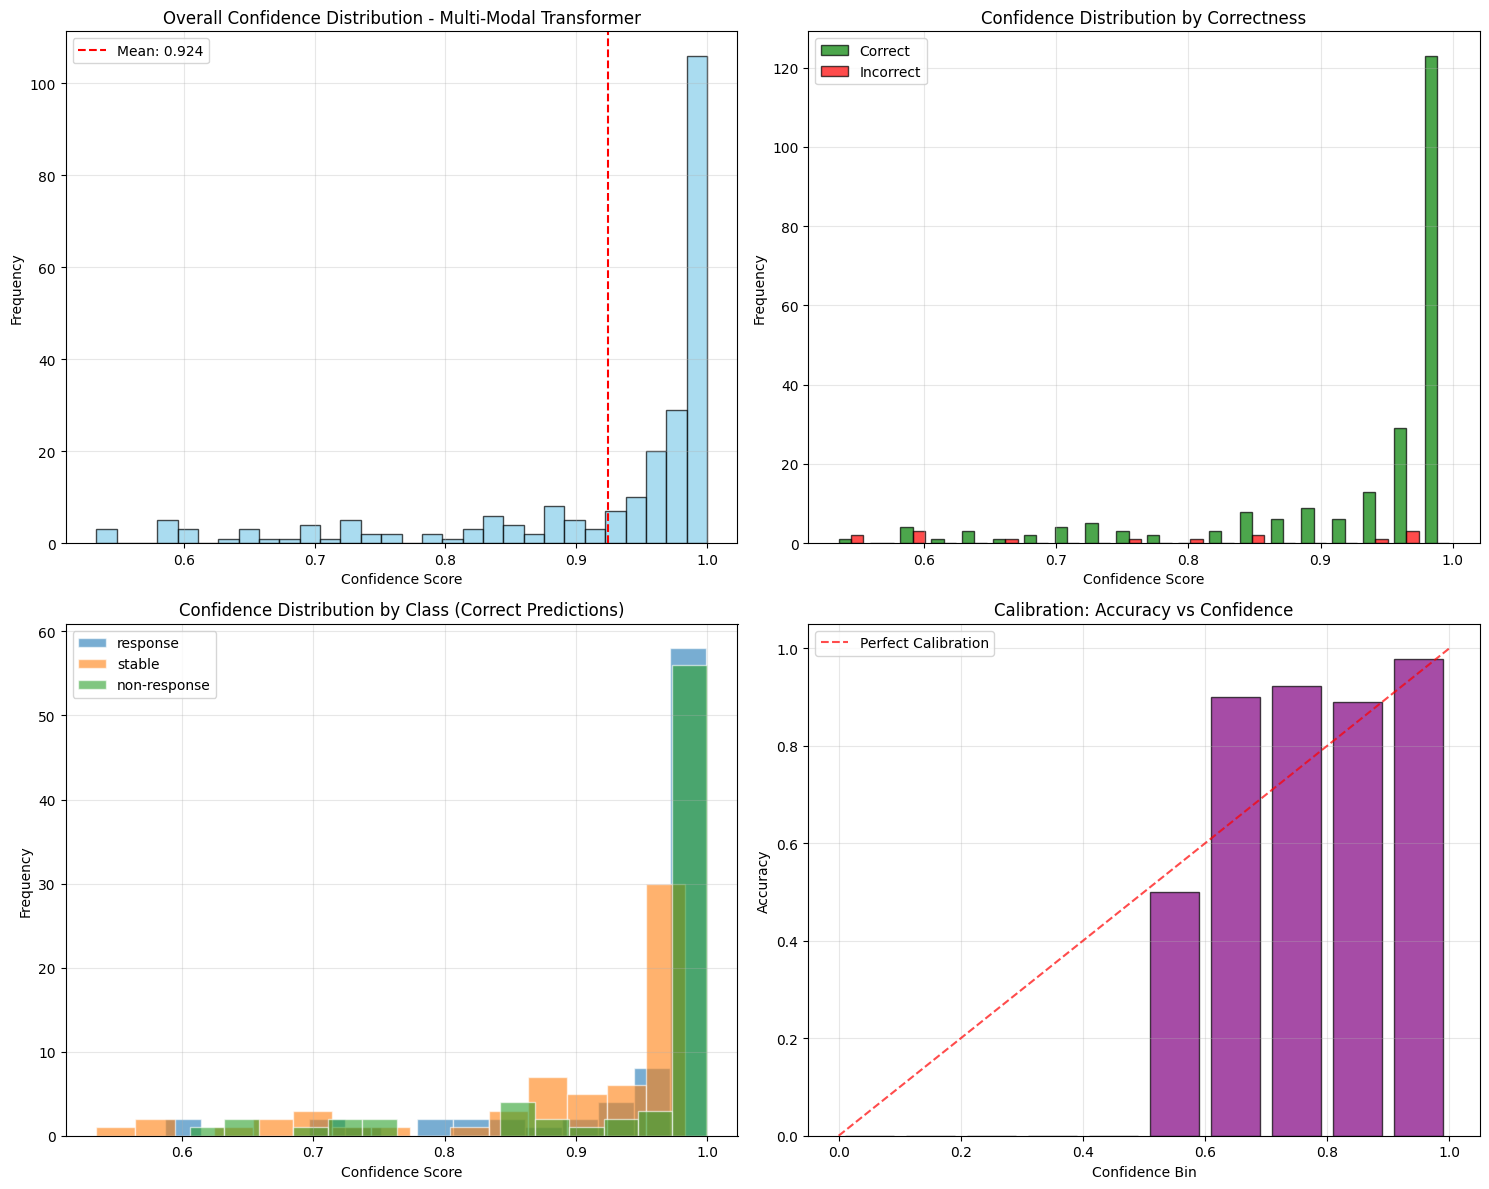


Confidence Analysis Summary for Multi-Modal Transformer:
  - Overall test accuracy: 0.9409
  - Average confidence: 0.9239
  - Confidence std: 0.1158
  - Correct predictions confidence: 0.9343 ± 0.1035
  - Incorrect predictions confidence: 0.7573 ± 0.1646

Per-class confidence analysis:
  response:
    - Sample count: 86
    - Accuracy: 0.9767
    - Average confidence: 0.9450
    - Correct predictions confidence: 0.9520
  stable:
    - Sample count: 74
    - Accuracy: 0.8514
    - Average confidence: 0.8718
    - Correct predictions confidence: 0.8918
  non-response:
    - Sample count: 77
    - Accuracy: 0.9870
    - Average confidence: 0.9504
    - Correct predictions confidence: 0.9500


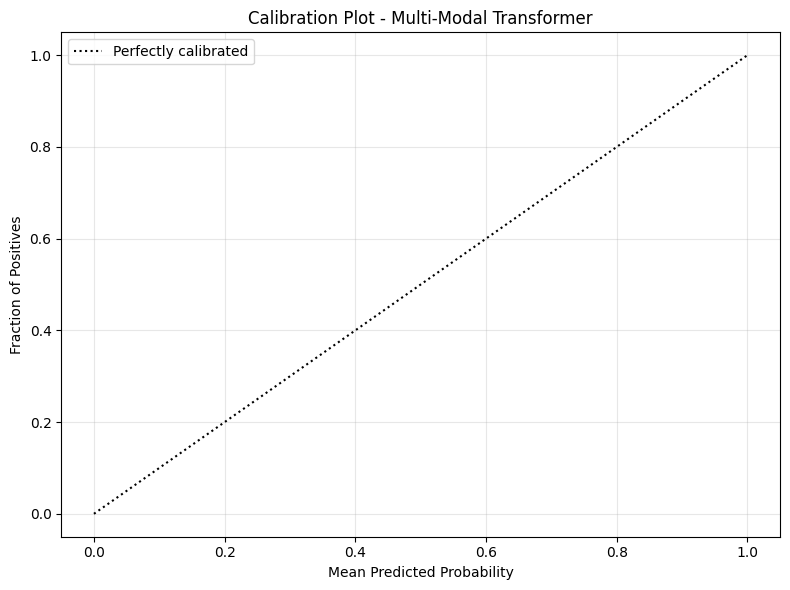


Expected Calibration Error (ECE):
  response: 0.0277
  stable: 0.0474
  non-response: 0.0251
  Overall (max prob): 0.0297


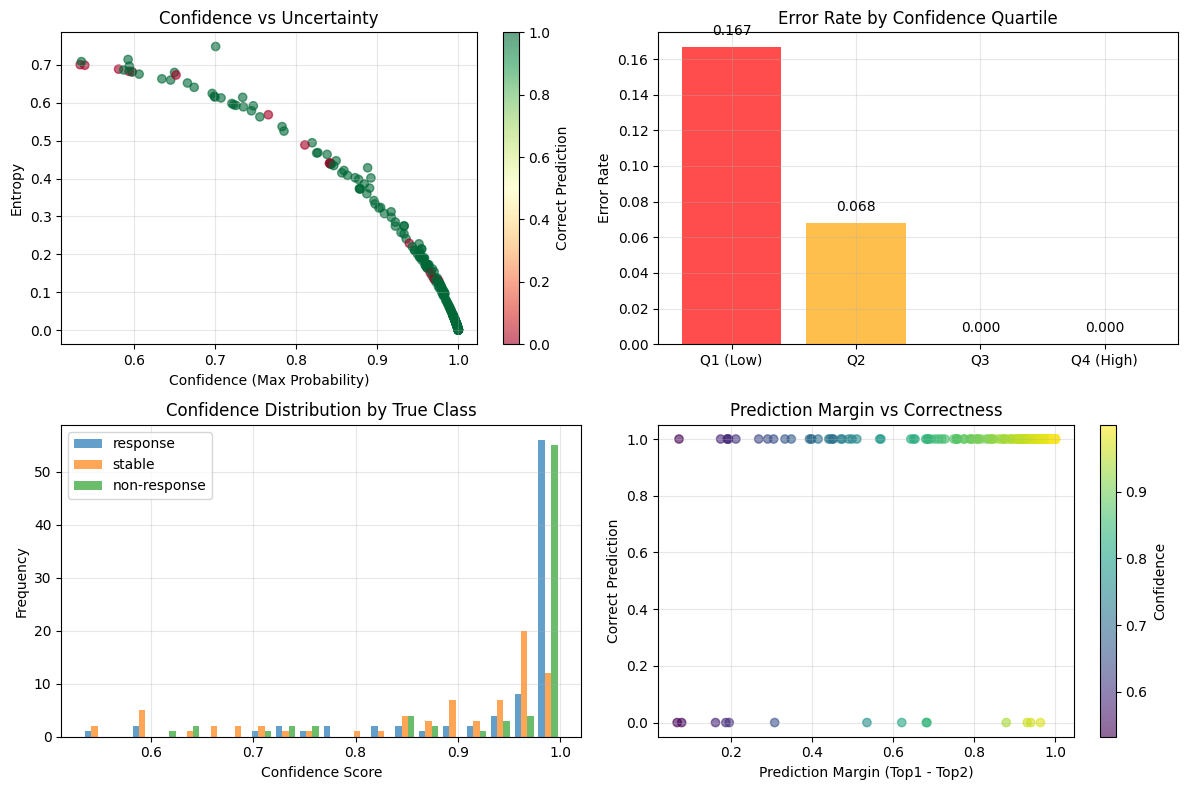


Uncertainty Analysis:
  - Average entropy: 0.1982
  - Average prediction margin: 0.8501
  - Correlation (confidence, margin): 0.9997
  - Correlation (confidence, correctness): 0.3604


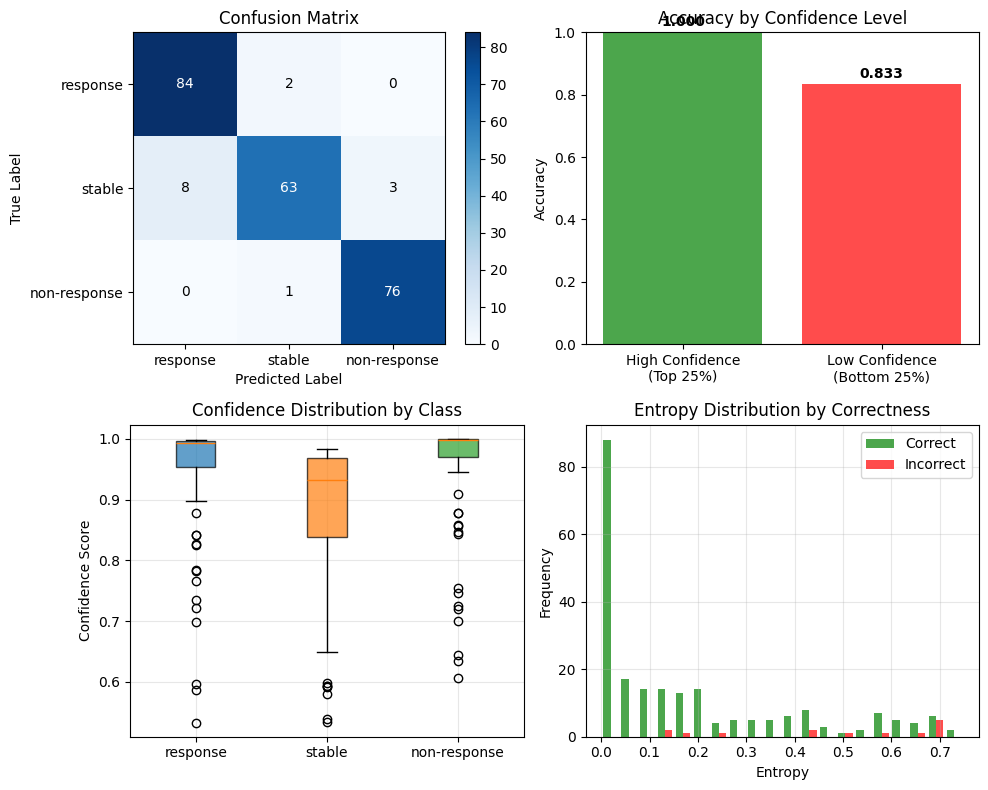


COMPREHENSIVE ANALYSIS SUMMARY

Model Performance:
  • Test Accuracy: 94.1%
  • Total Samples: 237
  • Correct Predictions: 223
  • Incorrect Predictions: 14

Confidence Statistics:
  • Mean Confidence: 0.9239
  • Confidence Range: 0.5330 - 0.9999
  • High Confidence (>75th percentile): 60 samples (100.0% accuracy)
  • Low Confidence (<25th percentile): 60 samples (83.3% accuracy)

Uncertainty Metrics:
  • Mean Entropy: 0.1982
  • Mean Prediction Margin: 0.8501
  • Confidence-Correctness Correlation: 0.3604

Files Generated:
  • multimodal_transformer_analysis/confidence_analysis.pdf
  • multimodal_transformer_analysis/calibration_curve.pdf
  • multimodal_transformer_analysis/uncertainty_analysis.pdf
  • multimodal_transformer_analysis/detailed_analysis.pdf


In [82]:
# Run the complete analysis
results = create_multimodal_confidence_analysis(
    model=model,
    test_set=test_set, 
    y_test=y_test,
    class_names=class_names
)

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from datetime import datetime

def save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test=None, 
                                filename=None, include_summary_page=True):
    """
    Save comprehensive confidence analysis as a PDF file
    """
    
    # Generate filename if not provided
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"confidence_analysis_{timestamp}.pdf"
    
    print(f"🔍 GENERATING CONFIDENCE ANALYSIS PDF: {filename}")
    print("=" * 60)
    
    # Get predictions and probabilities
    print("Getting model predictions...")
    y_test_prob = model.predict(test_set, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)
    
    # Convert all labels to integers
    y_test_int = np.array(y_test).astype(int)
    y_test_pred_int = np.array(y_test_pred).astype(int)
    
    # Calculate confidence metrics
    max_probs = np.max(y_test_prob, axis=1)
    pred_entropy = -np.sum(y_test_prob * np.log(y_test_prob + 1e-8), axis=1)
    correct_mask = (y_test_pred_int == y_test_int)
    
    # Separate confidence for correct vs incorrect predictions
    correct_conf = max_probs[correct_mask]
    incorrect_conf = max_probs[~correct_mask]
    correct_entropy = pred_entropy[correct_mask]
    incorrect_entropy = pred_entropy[~correct_mask]
    
    # Define confidence thresholds
    high_conf_thresh = 0.9
    low_conf_thresh = 0.7
    high_conf_mask = max_probs >= high_conf_thresh
    low_conf_mask = max_probs <= low_conf_thresh
    medium_conf_mask = (max_probs > low_conf_thresh) & (max_probs < high_conf_thresh)
    
    # Calculate group stats
    conf_groups = ['High (≥0.9)', 'Medium (0.7-0.9)', 'Low (≤0.7)']
    group_masks = [high_conf_mask, medium_conf_mask, low_conf_mask]
    group_accs = []
    group_counts = []
    
    for mask in group_masks:
        if np.sum(mask) > 0:
            group_accs.append(np.mean(correct_mask[mask]))
            group_counts.append(np.sum(mask))
        else:
            group_accs.append(0)
            group_counts.append(0)
    
    print(f"Test Accuracy: {np.mean(correct_mask):.4f}")
    print(f"Average Confidence: {np.mean(max_probs):.4f}")
    print(f"Total Samples: {len(y_test_int)}")
    
    # Create PDF
    with PdfPages(filename) as pdf:
        
        # =====================================
        # PAGE 1: Summary Statistics
        # =====================================
        if include_summary_page:
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size
            ax.axis('off')
            
            # Create comprehensive summary text
            summary_text = f"""
CONFIDENCE & UNCERTAINTY ANALYSIS REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

{'='*60}
EXECUTIVE SUMMARY
{'='*60}

Overall Performance:
• Test Accuracy: {np.mean(correct_mask):.1%}
• Total Test Samples: {len(y_test_int)}
• Classes: {', '.join(class_names)}

Confidence Distribution:
• Mean Confidence: {np.mean(max_probs):.3f}
• Standard Deviation: {np.std(max_probs):.3f}
• Range: {np.min(max_probs):.3f} - {np.max(max_probs):.3f}

Uncertainty Analysis:
• Mean Entropy: {np.mean(pred_entropy):.3f}
• Standard Deviation: {np.std(pred_entropy):.3f}

{'='*60}
CONFIDENCE GROUP BREAKDOWN
{'='*60}

High Confidence (≥90%):
• Samples: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[0]:.1%}

Medium Confidence (70-90%):
• Samples: {np.sum(medium_conf_mask)} ({np.sum(medium_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[1]:.1%}

Low Confidence (≤70%):
• Samples: {np.sum(low_conf_mask)} ({np.sum(low_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[2]:.1%}

{'='*60}
CLASS-WISE PERFORMANCE
{'='*60}
"""
            
            # Add class-wise statistics
            cm = confusion_matrix(y_test_int, y_test_pred_int)
            for i, class_name in enumerate(class_names):
                true_positives = cm[i, i]
                total_actual = np.sum(cm[i, :])
                total_predicted = np.sum(cm[:, i])
                
                if total_actual > 0:
                    recall = true_positives / total_actual
                    precision = true_positives / total_predicted if total_predicted > 0 else 0
                    class_mask = (y_test_int == i)
                    avg_conf = np.mean(max_probs[class_mask]) if np.sum(class_mask) > 0 else 0
                    
                    summary_text += f"""
{class_name}:
• Samples: {total_actual}
• Precision: {precision:.3f}
• Recall: {recall:.3f}
• Avg Confidence: {avg_conf:.3f}
"""
            
            if len(incorrect_conf) > 0:
                summary_text += f"""

{'='*60}
ERROR ANALYSIS
{'='*60}

Confidence Comparison:
• Correct Predictions: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}
• Incorrect Predictions: {np.mean(incorrect_conf):.3f} ± {np.std(incorrect_conf):.3f}
• Difference: {np.mean(correct_conf) - np.mean(incorrect_conf):.3f}

Uncertainty Comparison:
• Correct Predictions: {np.mean(correct_entropy):.3f} ± {np.std(correct_entropy):.3f}
• Incorrect Predictions: {np.mean(incorrect_entropy):.3f} ± {np.std(incorrect_entropy):.3f}
• Difference: {np.mean(incorrect_entropy) - np.mean(correct_entropy):.3f}

Most Problematic Cases:"""
                
                # Add most confident wrong predictions
                if len(incorrect_conf) > 0:
                    incorrect_indices = np.where(~correct_mask)[0]
                    most_confident_wrong = incorrect_indices[np.argsort(max_probs[incorrect_indices])[-min(5, len(incorrect_indices)):]]
                    for idx in most_confident_wrong:
                        pred_class_idx = int(y_test_pred_int[idx])
                        true_class_idx = int(y_test_int[idx])
                        summary_text += f"""
• Sample {idx}: {max_probs[idx]:.3f} confidence
  Predicted: {class_names[pred_class_idx]}
  Actual: {class_names[true_class_idx]}"""
            else:
                summary_text += f"""

{'='*60}
PERFECT PERFORMANCE!
{'='*60}

🎉 Your model achieved 100% accuracy on the test set!
No incorrect predictions to analyze.
"""
            
            summary_text += f"""

{'='*60}
CLINICAL RECOMMENDATIONS
{'='*60}

Based on this analysis:

1. High Confidence Predictions (≥90%):
   • {np.sum(high_conf_mask)} samples with {group_accs[0]:.1%} accuracy
   • Recommendation: Safe for automated processing

2. Medium Confidence Predictions (70-90%):
   • {np.sum(medium_conf_mask)} samples with {group_accs[1]:.1%} accuracy
   • Recommendation: Consider for automated processing with review

3. Low Confidence Predictions (≤70%):
   • {np.sum(low_conf_mask)} samples with {group_accs[2]:.1%} accuracy
   • Recommendation: Require human expert review

Model Calibration:
• Check calibration plot on next page
• Well-calibrated models have confidence ≈ accuracy

Next Steps:
• Review detailed visualizations in following pages
• Consider threshold optimization for clinical deployment
• Validate on external datasets before clinical use
"""
            
            ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top', fontfamily='monospace',
                   wrap=True)
            
            plt.title('Multi-Modal Transformer Confidence Analysis Report', 
                     fontsize=16, fontweight='bold', pad=20)
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()
        
        # =====================================
        # PAGE 2: Core Confidence Metrics
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))  # Landscape
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confidence Distribution
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.hist(correct_conf, bins=20, alpha=0.7, color='green', 
                label=f'Correct (n={len(correct_conf)})', density=True)
        if len(incorrect_conf) > 0:
            ax1.hist(incorrect_conf, bins=20, alpha=0.7, color='red', 
                    label=f'Incorrect (n={len(incorrect_conf)})', density=True)
            ax1.axvline(np.mean(incorrect_conf), color='red', linestyle='--', alpha=0.8)
        ax1.axvline(np.mean(correct_conf), color='green', linestyle='--', alpha=0.8)
        ax1.set_xlabel('Prediction Confidence')
        ax1.set_ylabel('Density')
        ax1.set_title('Confidence Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Entropy Distribution
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.hist(correct_entropy, bins=20, alpha=0.7, color='green', label='Correct', density=True)
        if len(incorrect_entropy) > 0:
            ax2.hist(incorrect_entropy, bins=20, alpha=0.7, color='red', label='Incorrect', density=True)
            ax2.axvline(np.mean(incorrect_entropy), color='red', linestyle='--', alpha=0.8)
        ax2.axvline(np.mean(correct_entropy), color='green', linestyle='--', alpha=0.8)
        ax2.set_xlabel('Prediction Entropy')
        ax2.set_ylabel('Density')
        ax2.set_title('Uncertainty (Entropy) Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Calibration Plot
        ax3 = fig.add_subplot(gs[1, 0])
        conf_bins = np.linspace(0, 1, 11)
        bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
        bin_accuracies = []
        bin_counts = []
        
        for i in range(len(conf_bins) - 1):
            mask = (max_probs >= conf_bins[i]) & (max_probs < conf_bins[i+1])
            if np.sum(mask) > 0:
                bin_acc = np.mean(correct_mask[mask])
                bin_accuracies.append(bin_acc)
                bin_counts.append(np.sum(mask))
            else:
                bin_accuracies.append(0)
                bin_counts.append(0)
        
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect Calibration')
        valid_bins = np.array(bin_counts) > 0
        if np.any(valid_bins):
            ax3.scatter(np.array(bin_centers)[valid_bins], np.array(bin_accuracies)[valid_bins], 
                       s=np.array(bin_counts)[valid_bins]*2, alpha=0.7, color='blue', label='Model Calibration')
        ax3.set_xlabel('Confidence')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('Calibration Plot (Size = Sample Count)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, 1)
        ax3.set_ylim(0, 1)
        
        # Confidence by Class
        ax4 = fig.add_subplot(gs[1, 1])
        conf_by_class = []
        for cls in range(len(class_names)):
            class_mask = (y_test_int == cls)
            class_conf = max_probs[class_mask]
            conf_by_class.append(class_conf)
        
        if any(len(conf) > 0 for conf in conf_by_class):
            bp = ax4.boxplot(conf_by_class, labels=class_names, patch_artist=True)
            colors = ['lightblue', 'lightgreen', 'lightcoral']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
        
        ax4.set_ylabel('Confidence')
        ax4.set_title('Confidence by True Class')
        ax4.grid(True, alpha=0.3)
        
        plt.suptitle('Core Confidence & Uncertainty Metrics', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 3: Performance Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confusion Matrix - VIRIDIS COLORMAP
        ax1 = fig.add_subplot(gs[0, :])
        cm = confusion_matrix(y_test_int, y_test_pred_int)
        conf_cm = np.zeros_like(cm, dtype=float)
        for true_cls in range(len(class_names)):
            for pred_cls in range(len(class_names)):
                mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
                if np.sum(mask) > 0:
                    conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
        
        im = ax1.imshow(cm, interpolation='nearest', cmap='viridis')
        fig.colorbar(im, ax=ax1)
        
        thresh = cm.max() / 2. if cm.max() > 0 else 0.5
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax1.text(j, i - 0.1, f'{cm[i, j]}', 
                        ha='center', va='center', fontsize=12,
                        color='white' if cm[i, j] > thresh else 'black')
                if cm[i, j] > 0:
                    ax1.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                            ha='center', va='center', fontsize=9, color='red')
        
        ax1.set_xticks(range(len(class_names)))
        ax1.set_yticks(range(len(class_names)))
        ax1.set_xticklabels(class_names)
        ax1.set_yticklabels(class_names)
        ax1.set_title('Confusion Matrix with Average Confidence')
        ax1.set_ylabel('True Label')
        ax1.set_xlabel('Predicted Label')
        
        # SAVE CONFUSION MATRIX AS SEPARATE PNG FILE
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        cm_filename = f'confusion_matrix_{timestamp}.png'
        
        fig_cm = plt.figure(figsize=(10, 8))
        ax_cm = fig_cm.add_subplot(111)
        im_cm = ax_cm.imshow(cm, interpolation='nearest', cmap='viridis')
        cbar_cm = fig_cm.colorbar(im_cm, ax=ax_cm)
        cbar_cm.set_label('Number of Samples', rotation=270, labelpad=20)
        
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax_cm.text(j, i - 0.1, f'{cm[i, j]}', 
                          ha='center', va='center', fontsize=12,
                          color='white' if cm[i, j] > thresh else 'black',
                          fontweight='bold')
                if cm[i, j] > 0:
                    ax_cm.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                              ha='center', va='center', fontsize=9, 
                              color='red', fontweight='bold')
        
        ax_cm.set_xticks(range(len(class_names)))
        ax_cm.set_yticks(range(len(class_names)))
        ax_cm.set_xticklabels(class_names, fontsize=11)
        ax_cm.set_yticklabels(class_names, fontsize=11)
        ax_cm.set_title('Confusion Matrix with Average Confidence', 
                       fontsize=14, fontweight='bold', pad=15)
        ax_cm.set_ylabel('True Label', fontsize=12, fontweight='bold')
        ax_cm.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(cm_filename, dpi=300, bbox_inches='tight')
        print(f"✅ Confusion matrix saved: {cm_filename}")
        plt.close(fig_cm)
        
        # Confidence Groups
        ax2 = fig.add_subplot(gs[1, 0])
        bars = ax2.bar(conf_groups, group_accs, color=['green', 'orange', 'red'], alpha=0.7)
        for bar, count in zip(bars, group_counts):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'n={count}', ha='center', va='bottom', fontweight='bold')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy by Confidence Level')
        ax2.set_ylim(0, 1.1)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Numeric Feature vs Confidence (if available)
        ax3 = fig.add_subplot(gs[1, 1])
        if X_num_test is not None:
            numeric_values = X_num_test.flatten()
            correct_indices = np.where(correct_mask)[0]
            incorrect_indices = np.where(~correct_mask)[0]
            
            if len(correct_indices) > 0:
                ax3.scatter(numeric_values[correct_indices], max_probs[correct_indices], 
                           color='green', alpha=0.6, label='Correct', s=20)
            if len(incorrect_indices) > 0:
                ax3.scatter(numeric_values[incorrect_indices], max_probs[incorrect_indices], 
                           color='red', alpha=0.8, label='Incorrect', s=20)
            
            ax3.set_xlabel('Standardized Elastic Modulus (kPa)')
            ax3.set_ylabel('Prediction Confidence')
            ax3.set_title('Numeric Feature vs Confidence')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Numeric features not provided', 
                    ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Numeric Feature Analysis')
        
        plt.suptitle('Detailed Performance Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 4: Sample Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
        
        # Probability Distribution
        ax1 = fig.add_subplot(gs[0, :])
        x_pos = np.arange(len(y_test_int))
        bottom = np.zeros(len(y_test_int))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        
        for cls in range(len(class_names)):
            ax1.bar(x_pos, y_test_prob[:, cls], bottom=bottom, 
                   color=colors[cls % len(colors)], alpha=0.7, label=class_names[cls])
            bottom += y_test_prob[:, cls]
        
        incorrect_indices = np.where(~correct_mask)[0]
        for idx in incorrect_indices:
            ax1.axvline(idx, color='red', alpha=0.3, linewidth=0.5)
        
        ax1.set_xlabel('Test Sample Index')
        ax1.set_ylabel('Probability')
        ax1.set_title('Prediction Probabilities (Red lines = Incorrect predictions)')
        ax1.legend()
        ax1.set_xlim(0, len(y_test_int))
        
        # Most Confident Correct
        ax2 = fig.add_subplot(gs[1, 0])
        if np.sum(correct_mask) > 0:
            most_conf_correct = np.where(correct_mask)[0][np.argsort(max_probs[correct_mask])[-min(10, np.sum(correct_mask)):]]
            conf_values = max_probs[most_conf_correct]
            ax2.barh(range(len(most_conf_correct)), conf_values, color='green', alpha=0.7)
            ax2.set_xlabel('Confidence')
            ax2.set_title('Most Confident Correct')
            ax2.set_yticks(range(len(most_conf_correct)))
            ax2.set_yticklabels([f'S{i}' for i in most_conf_correct])
            ax2.grid(True, alpha=0.3, axis='x')
        else:
            ax2.text(0.5, 0.5, 'No correct\npredictions!', ha='center', va='center', 
                    transform=ax2.transAxes, color='red', fontweight='bold')
        
        # Most Confident Incorrect
        ax3 = fig.add_subplot(gs[1, 1])
        if np.sum(~correct_mask) > 0:
            most_conf_incorrect = np.where(~correct_mask)[0][np.argsort(max_probs[~correct_mask])[-min(10, np.sum(~correct_mask)):]]
            conf_values_inc = max_probs[most_conf_incorrect]
            ax3.barh(range(len(most_conf_incorrect)), conf_values_inc, color='red', alpha=0.7)
            ax3.set_xlabel('Confidence')
            ax3.set_title('Most Confident Incorrect')
            ax3.set_yticks(range(len(most_conf_incorrect)))
            ax3.set_yticklabels([f'S{i}' for i in most_conf_incorrect])
            ax3.grid(True, alpha=0.3, axis='x')
        else:
            ax3.text(0.5, 0.5, 'Perfect\nAccuracy!', ha='center', va='center', 
                    transform=ax3.transAxes, color='green', fontweight='bold')
        
        # Least Confident
        ax4 = fig.add_subplot(gs[1, 2])
        least_confident = np.argsort(max_probs)[:min(10, len(max_probs))]
        least_conf_values = max_probs[least_confident]
        colors_least = ['green' if correct_mask[i] else 'red' for i in least_confident]
        ax4.barh(range(len(least_confident)), least_conf_values, color=colors_least, alpha=0.7)
        ax4.set_xlabel('Confidence')
        ax4.set_title('Least Confident')
        ax4.set_yticks(range(len(least_confident)))
        ax4.set_yticklabels([f'S{i}' for i in least_confident])
        ax4.grid(True, alpha=0.3, axis='x')
        
        plt.suptitle('Sample-Level Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        print(f"✅ PDF saved successfully: {filename}")
        print(f"📄 Pages: {4 if include_summary_page else 3}")
        print(f"📊 Analysis complete!")
    
    return {
        'probabilities': y_test_prob,
        'predictions': y_test_pred_int,
        'true_labels': y_test_int,
        'confidences': max_probs,
        'entropies': pred_entropy,
        'correct_mask': correct_mask,
        'filename': filename
    }

# Usage example:
# results = save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test)

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from datetime import datetime

def save_confusion_matrix_separate(y_test_int, y_test_pred_int, max_probs, class_names, 
                                   filename='confusion_matrix.png', dpi=300, colormap='viridis'):
    """
    Save confusion matrix with average confidence as a separate file
    
    Parameters:
    -----------
    y_test_int : array-like
        True labels as integers
    y_test_pred_int : array-like
        Predicted labels as integers
    max_probs : array-like
        Maximum probabilities (confidence) for each prediction
    class_names : list
        List of class names
    filename : str
        Output filename (supports .png, .jpg, .pdf, .svg)
    dpi : int
        Resolution for the saved figure
    colormap : str
        Matplotlib colormap name (default: 'viridis')
    """
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_int, y_test_pred_int)
    
    # Calculate average confidence for each cell
    conf_cm = np.zeros_like(cm, dtype=float)
    for true_cls in range(len(class_names)):
        for pred_cls in range(len(class_names)):
            mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
            if np.sum(mask) > 0:
                conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
    
    # Plot confusion matrix with viridis colormap
    im = ax.imshow(cm, interpolation='nearest', cmap=colormap)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Number of Samples', rotation=270, labelpad=20)
    
    # Add text annotations
    thresh = cm.max() / 2. if cm.max() > 0 else 0.5
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            # Sample count (white or black depending on background)
            ax.text(j, i - 0.1, f'{cm[i, j]}', 
                   ha='center', va='center', fontsize=16,
                   color='white' if cm[i, j] > thresh else 'black',
                   fontweight='bold')
            # Average confidence (in red for visibility)
            if cm[i, j] > 0:
                ax.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                       ha='center', va='center', fontsize=9, 
                       color='red', fontweight='bold')
    
    # Set labels and title
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_title('Confusion Matrix with Average Confidence', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    print(f"✅ Confusion matrix saved: {filename}")
    plt.close()
    
    return cm, conf_cm


def save_confidence_analysis_pdf(model, test_set, y_test, class_names, X_num_test=None, 
                                filename=None, include_summary_page=True,
                                save_separate_confusion_matrix=True,
                                confusion_matrix_colormap='viridis'):
    """
    Save comprehensive confidence analysis as a PDF file
    """
    
    # Generate filename if not provided
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"confidence_analysis_{timestamp}.pdf"
    else:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print(f"🔍 GENERATING CONFIDENCE ANALYSIS PDF: {filename}")
    print("=" * 60)
    
    # Get predictions and probabilities
    print("Getting model predictions...")
    y_test_prob = model.predict(test_set, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)
    
    # Convert all labels to integers
    y_test_int = np.array(y_test).astype(int)
    y_test_pred_int = np.array(y_test_pred).astype(int)
    
    # Calculate confidence metrics
    max_probs = np.max(y_test_prob, axis=1)
    pred_entropy = -np.sum(y_test_prob * np.log(y_test_prob + 1e-8), axis=1)
    correct_mask = (y_test_pred_int == y_test_int)
    
    # Separate confidence for correct vs incorrect predictions
    correct_conf = max_probs[correct_mask]
    incorrect_conf = max_probs[~correct_mask]
    correct_entropy = pred_entropy[correct_mask]
    incorrect_entropy = pred_entropy[~correct_mask]
    
    # Define confidence thresholds
    high_conf_thresh = 0.9
    low_conf_thresh = 0.7
    high_conf_mask = max_probs >= high_conf_thresh
    low_conf_mask = max_probs <= low_conf_thresh
    medium_conf_mask = (max_probs > low_conf_thresh) & (max_probs < high_conf_thresh)
    
    # Calculate group stats
    conf_groups = ['High (≥0.9)', 'Medium (0.7-0.9)', 'Low (≤0.7)']
    group_masks = [high_conf_mask, medium_conf_mask, low_conf_mask]
    group_accs = []
    group_counts = []
    
    for mask in group_masks:
        if np.sum(mask) > 0:
            group_accs.append(np.mean(correct_mask[mask]))
            group_counts.append(np.sum(mask))
        else:
            group_accs.append(0)
            group_counts.append(0)
    
    print(f"Test Accuracy: {np.mean(correct_mask):.4f}")
    print(f"Average Confidence: {np.mean(max_probs):.4f}")
    print(f"Total Samples: {len(y_test_int)}")
    
    # Save separate confusion matrix if requested
    if save_separate_confusion_matrix:
        cm_filename = filename.replace('.pdf', f'_confusion_matrix_{timestamp}.png')
        save_confusion_matrix_separate(
            y_test_int, 
            y_test_pred_int, 
            max_probs, 
            class_names,
            filename=cm_filename,
            dpi=300,
            colormap=confusion_matrix_colormap
        )
    
    # Create PDF
    with PdfPages(filename) as pdf:
        
        # =====================================
        # PAGE 1: Summary Statistics
        # =====================================
        if include_summary_page:
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size
            ax.axis('off')
            
            # Create comprehensive summary text
            summary_text = f"""
CONFIDENCE & UNCERTAINTY ANALYSIS REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

{'='*60}
EXECUTIVE SUMMARY
{'='*60}

Overall Performance:
• Test Accuracy: {np.mean(correct_mask):.1%}
• Total Test Samples: {len(y_test_int)}
• Classes: {', '.join(class_names)}

Confidence Distribution:
• Mean Confidence: {np.mean(max_probs):.3f}
• Standard Deviation: {np.std(max_probs):.3f}
• Range: {np.min(max_probs):.3f} - {np.max(max_probs):.3f}

Uncertainty Analysis:
• Mean Entropy: {np.mean(pred_entropy):.3f}
• Standard Deviation: {np.std(pred_entropy):.3f}

{'='*60}
CONFIDENCE GROUP BREAKDOWN
{'='*60}

High Confidence (≥90%):
• Samples: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[0]:.1%}

Medium Confidence (70-90%):
• Samples: {np.sum(medium_conf_mask)} ({np.sum(medium_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[1]:.1%}

Low Confidence (≤70%):
• Samples: {np.sum(low_conf_mask)} ({np.sum(low_conf_mask)/len(y_test_int)*100:.1f}%)
• Accuracy: {group_accs[2]:.1%}

{'='*60}
CLASS-WISE PERFORMANCE
{'='*60}
"""
            
            # Add class-wise statistics
            cm = confusion_matrix(y_test_int, y_test_pred_int)
            for i, class_name in enumerate(class_names):
                true_positives = cm[i, i]
                total_actual = np.sum(cm[i, :])
                total_predicted = np.sum(cm[:, i])
                
                if total_actual > 0:
                    recall = true_positives / total_actual
                    precision = true_positives / total_predicted if total_predicted > 0 else 0
                    class_mask = (y_test_int == i)
                    avg_conf = np.mean(max_probs[class_mask]) if np.sum(class_mask) > 0 else 0
                    
                    summary_text += f"""
{class_name}:
• Samples: {total_actual}
• Precision: {precision:.3f}
• Recall: {recall:.3f}
• Avg Confidence: {avg_conf:.3f}
"""
            
            if len(incorrect_conf) > 0:
                summary_text += f"""

{'='*60}
ERROR ANALYSIS
{'='*60}

Confidence Comparison:
• Correct Predictions: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}
• Incorrect Predictions: {np.mean(incorrect_conf):.3f} ± {np.std(incorrect_conf):.3f}
• Difference: {np.mean(correct_conf) - np.mean(incorrect_conf):.3f}

Uncertainty Comparison:
• Correct Predictions: {np.mean(correct_entropy):.3f} ± {np.std(correct_entropy):.3f}
• Incorrect Predictions: {np.mean(incorrect_entropy):.3f} ± {np.std(incorrect_entropy):.3f}
• Difference: {np.mean(incorrect_entropy) - np.mean(correct_entropy):.3f}

Most Problematic Cases:"""
                
                # Add most confident wrong predictions
                if len(incorrect_conf) > 0:
                    incorrect_indices = np.where(~correct_mask)[0]
                    most_confident_wrong = incorrect_indices[np.argsort(max_probs[incorrect_indices])[-min(5, len(incorrect_indices)):]]
                    for idx in most_confident_wrong:
                        pred_class_idx = int(y_test_pred_int[idx])
                        true_class_idx = int(y_test_int[idx])
                        summary_text += f"""
• Sample {idx}: {max_probs[idx]:.3f} confidence
  Predicted: {class_names[pred_class_idx]}
  Actual: {class_names[true_class_idx]}"""
            else:
                summary_text += f"""

{'='*60}
PERFECT PERFORMANCE!
{'='*60}

🎉 Your model achieved 100% accuracy on the test set!
No incorrect predictions to analyze.
"""
            
            summary_text += f"""

{'='*60}
CLINICAL RECOMMENDATIONS
{'='*60}

Based on this analysis:

1. High Confidence Predictions (≥90%):
   • {np.sum(high_conf_mask)} samples with {group_accs[0]:.1%} accuracy
   • Recommendation: Safe for automated processing

2. Medium Confidence Predictions (70-90%):
   • {np.sum(medium_conf_mask)} samples with {group_accs[1]:.1%} accuracy
   • Recommendation: Consider for automated processing with review

3. Low Confidence Predictions (≤70%):
   • {np.sum(low_conf_mask)} samples with {group_accs[2]:.1%} accuracy
   • Recommendation: Require human expert review

Model Calibration:
• Check calibration plot on next page
• Well-calibrated models have confidence ≈ accuracy

Next Steps:
• Review detailed visualizations in following pages
• Consider threshold optimization for clinical deployment
• Validate on external datasets before clinical use
"""
            
            ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top', fontfamily='monospace',
                   wrap=True)
            
            plt.title('Multi-Modal Transformer Confidence Analysis Report', 
                     fontsize=16, fontweight='bold', pad=20)
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()
        
        # =====================================
        # PAGE 2: Core Confidence Metrics
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))  # Landscape
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confidence Distribution
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.hist(correct_conf, bins=20, alpha=0.7, color='green', 
                label=f'Correct (n={len(correct_conf)})', density=True)
        if len(incorrect_conf) > 0:
            ax1.hist(incorrect_conf, bins=20, alpha=0.7, color='red', 
                    label=f'Incorrect (n={len(incorrect_conf)})', density=True)
            ax1.axvline(np.mean(incorrect_conf), color='red', linestyle='--', alpha=0.8)
        ax1.axvline(np.mean(correct_conf), color='green', linestyle='--', alpha=0.8)
        ax1.set_xlabel('Prediction Confidence')
        ax1.set_ylabel('Density')
        ax1.set_title('Confidence Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Entropy Distribution
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.hist(correct_entropy, bins=20, alpha=0.7, color='green', label='Correct', density=True)
        if len(incorrect_entropy) > 0:
            ax2.hist(incorrect_entropy, bins=20, alpha=0.7, color='red', label='Incorrect', density=True)
            ax2.axvline(np.mean(incorrect_entropy), color='red', linestyle='--', alpha=0.8)
        ax2.axvline(np.mean(correct_entropy), color='green', linestyle='--', alpha=0.8)
        ax2.set_xlabel('Prediction Entropy')
        ax2.set_ylabel('Density')
        ax2.set_title('Uncertainty (Entropy) Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Calibration Plot
        ax3 = fig.add_subplot(gs[1, 0])
        conf_bins = np.linspace(0, 1, 11)
        bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
        bin_accuracies = []
        bin_counts = []
        
        for i in range(len(conf_bins) - 1):
            mask = (max_probs >= conf_bins[i]) & (max_probs < conf_bins[i+1])
            if np.sum(mask) > 0:
                bin_acc = np.mean(correct_mask[mask])
                bin_accuracies.append(bin_acc)
                bin_counts.append(np.sum(mask))
            else:
                bin_accuracies.append(0)
                bin_counts.append(0)
        
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect Calibration')
        valid_bins = np.array(bin_counts) > 0
        if np.any(valid_bins):
            ax3.scatter(np.array(bin_centers)[valid_bins], np.array(bin_accuracies)[valid_bins], 
                       s=np.array(bin_counts)[valid_bins]*2, alpha=0.7, color='blue', label='Model Calibration')
        ax3.set_xlabel('Confidence')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('Calibration Plot (Size = Sample Count)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, 1)
        ax3.set_ylim(0, 1)
        
        # Confidence by Class
        ax4 = fig.add_subplot(gs[1, 1])
        conf_by_class = []
        for cls in range(len(class_names)):
            class_mask = (y_test_int == cls)
            class_conf = max_probs[class_mask]
            conf_by_class.append(class_conf)
        
        if any(len(conf) > 0 for conf in conf_by_class):
            bp = ax4.boxplot(conf_by_class, labels=class_names, patch_artist=True)
            colors = ['lightblue', 'lightgreen', 'lightcoral']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
        
        ax4.set_ylabel('Confidence')
        ax4.set_title('Confidence by True Class')
        ax4.grid(True, alpha=0.3)
        
        plt.suptitle('Core Confidence & Uncertainty Metrics', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 3: Performance Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Confusion Matrix with VIRIDIS colormap
        ax1 = fig.add_subplot(gs[0, :])
        cm = confusion_matrix(y_test_int, y_test_pred_int)
        conf_cm = np.zeros_like(cm, dtype=float)
        for true_cls in range(len(class_names)):
            for pred_cls in range(len(class_names)):
                mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
                if np.sum(mask) > 0:
                    conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
        
        im = ax1.imshow(cm, interpolation='nearest', cmap=confusion_matrix_colormap)
        cbar = fig.colorbar(im, ax=ax1)
        cbar.set_label('Count', rotation=270, labelpad=15)
        
        thresh = cm.max() / 2. if cm.max() > 0 else 0.5
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax1.text(j, i - 0.1, f'{cm[i, j]}', 
                        ha='center', va='center', fontsize=12,
                        color='white' if cm[i, j] > thresh else 'black')
                if cm[i, j] > 0:
                    ax1.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                            ha='center', va='center', fontsize=9, color='red')
        
        ax1.set_xticks(range(len(class_names)))
        ax1.set_yticks(range(len(class_names)))
        ax1.set_xticklabels(class_names)
        ax1.set_yticklabels(class_names)
        ax1.set_title('Confusion Matrix with Average Confidence')
        ax1.set_ylabel('True Label')
        ax1.set_xlabel('Predicted Label')
        
        # Confidence Groups
        ax2 = fig.add_subplot(gs[1, 0])
        bars = ax2.bar(conf_groups, group_accs, color=['green', 'orange', 'red'], alpha=0.7)
        for bar, count in zip(bars, group_counts):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'n={count}', ha='center', va='bottom', fontweight='bold')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy by Confidence Level')
        ax2.set_ylim(0, 1.1)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Numeric Feature vs Confidence (if available)
        ax3 = fig.add_subplot(gs[1, 1])
        if X_num_test is not None:
            numeric_values = X_num_test.flatten()
            correct_indices = np.where(correct_mask)[0]
            incorrect_indices = np.where(~correct_mask)[0]
            
            if len(correct_indices) > 0:
                ax3.scatter(numeric_values[correct_indices], max_probs[correct_indices], 
                           color='green', alpha=0.6, label='Correct', s=20)
            if len(incorrect_indices) > 0:
                ax3.scatter(numeric_values[incorrect_indices], max_probs[incorrect_indices], 
                           color='red', alpha=0.8, label='Incorrect', s=20)
            
            ax3.set_xlabel('Standardized Elastic Modulus (kPa)')
            ax3.set_ylabel('Prediction Confidence')
            ax3.set_title('Numeric Feature vs Confidence')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Numeric features not provided', 
                    ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Numeric Feature Analysis')
        
        plt.suptitle('Detailed Performance Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        # =====================================
        # PAGE 4: Sample Analysis
        # =====================================
        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
        
        # Probability Distribution
        ax1 = fig.add_subplot(gs[0, :])
        x_pos = np.arange(len(y_test_int))
        bottom = np.zeros(len(y_test_int))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        
        for cls in range(len(class_names)):
            ax1.bar(x_pos, y_test_prob[:, cls], bottom=bottom, 
                   color=colors[cls % len(colors)], alpha=0.7, label=class_names[cls])
            bottom += y_test_prob[:, cls]
        
        incorrect_indices = np.where(~correct_mask)[0]
        for idx in incorrect_indices:
            ax1.axvline(idx, color='red', alpha=0.3, linewidth=0.5)
        
        ax1.set_xlabel('Test Sample Index')
        ax1.set_ylabel('Probability')
        ax1.set_title('Prediction Probabilities (Red lines = Incorrect predictions)')
        ax1.legend()
        ax1.set_xlim(0, len(y_test_int))
        
        # Most Confident Correct
        ax2 = fig.add_subplot(gs[1, 0])
        if np.sum(correct_mask) > 0:
            most_conf_correct = np.where(correct_mask)[0][np.argsort(max_probs[correct_mask])[-min(10, np.sum(correct_mask)):]]
            conf_values = max_probs[most_conf_correct]
            ax2.barh(range(len(most_conf_correct)), conf_values, color='green', alpha=0.7)
            ax2.set_xlabel('Confidence')
            ax2.set_title('Most Confident Correct')
            ax2.set_yticks(range(len(most_conf_correct)))
            ax2.set_yticklabels([f'S{i}' for i in most_conf_correct])
            ax2.grid(True, alpha=0.3, axis='x')
        else:
            ax2.text(0.5, 0.5, 'No correct\npredictions!', ha='center', va='center', 
                    transform=ax2.transAxes, color='red', fontweight='bold')
        
        # Most Confident Incorrect
        ax3 = fig.add_subplot(gs[1, 1])
        if np.sum(~correct_mask) > 0:
            most_conf_incorrect = np.where(~correct_mask)[0][np.argsort(max_probs[~correct_mask])[-min(10, np.sum(~correct_mask)):]]
            conf_values_inc = max_probs[most_conf_incorrect]
            ax3.barh(range(len(most_conf_incorrect)), conf_values_inc, color='red', alpha=0.7)
            ax3.set_xlabel('Confidence')
            ax3.set_title('Most Confident Incorrect')
            ax3.set_yticks(range(len(most_conf_incorrect)))
            ax3.set_yticklabels([f'S{i}' for i in most_conf_incorrect])
            ax3.grid(True, alpha=0.3, axis='x')
        else:
            ax3.text(0.5, 0.5, 'Perfect\nAccuracy!', ha='center', va='center', 
                    transform=ax3.transAxes, color='green', fontweight='bold')
        
        # Least Confident
        ax4 = fig.add_subplot(gs[1, 2])
        least_confident = np.argsort(max_probs)[:min(10, len(max_probs))]
        least_conf_values = max_probs[least_confident]
        colors_least = ['green' if correct_mask[i] else 'red' for i in least_confident]
        ax4.barh(range(len(least_confident)), least_conf_values, color=colors_least, alpha=0.7)
        ax4.set_xlabel('Confidence')
        ax4.set_title('Least Confident')
        ax4.set_yticks(range(len(least_confident)))
        ax4.set_yticklabels([f'S{i}' for i in least_confident])
        ax4.grid(True, alpha=0.3, axis='x')
        
        plt.suptitle('Sample-Level Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()
        
        print(f"✅ PDF saved successfully: {filename}")
        print(f"📄 Pages: {4 if include_summary_page else 3}")
        print(f"📊 Analysis complete!")
    
    return {
        'probabilities': y_test_prob,
        'predictions': y_test_pred_int,
        'true_labels': y_test_int,
        'confidences': max_probs,
        'entropies': pred_entropy,
        'correct_mask': correct_mask,
        'filename': filename
    }


# =====================================
# EXAMPLE USAGE
# =====================================

if __name__ == "__main__":
    """
    Example usage of the confidence analysis functions
    """
    
    # Assuming you have:
    # - model: your trained Keras/TensorFlow model
    # - test_set: your test dataset (TensorFlow dataset or similar)
    # - y_test: true labels
    # - class_names: list of class names
    # - X_num_test: (optional) numeric features for additional analysis
    
    # Example 1: Basic usage with automatic filename and separate confusion matrix
    # results = save_confidence_analysis_pdf(
    #     model=model,
    #     test_set=test_set,
    #     y_test=y_test,
    #     class_names=['Benign', 'Malignant', 'Normal'],
    #     X_num_test=X_num_test
    # )
    
    # Example 2: Custom filename with viridis confusion matrix
    # results = save_confidence_analysis_pdf(
    #     model=model,
    #     test_set=test_set,
    #     y_test=y_test,
    #     class_names=['Benign', 'Malignant', 'Normal'],
    #     X_num_test=X_num_test,
    #     filename="my_model_analysis.pdf",
    #     save_separate_confusion_matrix=True,
    #     confusion_matrix_colormap='viridis'
    # )
    
    # Example 3: Try different colormaps
    # results = save_confidence_analysis_pdf(
    #     model=model,
    #     test_set=test_set,
    #     y_test=y_test,
    #     class_names=['Benign', 'Malignant', 'Normal'],
    #     X_num_test=X_num_test,
    #     filename="analysis_plasma.pdf"

In [87]:
# First, get predictions from your model
y_test_prob = model.predict(test_set, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Convert labels to integers
y_test_int = np.array(y_test).astype(int)
y_test_pred_int = np.array(y_test_pred).astype(int)

# Calculate max probabilities (confidence)
max_probs = np.max(y_test_prob, axis=1)

# Now call the function
save_confusion_matrix_separate(
    y_test_int, 
    y_test_pred_int, 
    max_probs, 
    class_names=['Benign', 'Malignant', 'Normal'],  # or whatever your class names are
    filename='confusion_matrix_viridis.pdf',
    dpi=300,
    colormap='viridis'
)

✅ Confusion matrix saved: confusion_matrix_viridis.pdf


(array([[84,  2,  0],
        [ 8, 63,  3],
        [ 0,  1, 76]]),
 array([[0.95204896, 0.64915156, 0.        ],
        [0.74381357, 0.89181077, 0.79248601],
        [0.        , 0.97584844, 0.95002264]]))

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def save_confusion_matrix_separate(y_test_int, y_test_pred_int, max_probs, class_names, 
                                   filename='confusion_matrix.png', dpi=300, colormap='viridis'):
    """
    Save confusion matrix with average confidence as a separate file
    WITH LARGE FONTS
    
    Parameters:
    -----------
    y_test_int : array-like
        True labels as integers
    y_test_pred_int : array-like
        Predicted labels as integers
    max_probs : array-like
        Maximum probabilities (confidence) for each prediction
    class_names : list
        List of class names
    filename : str
        Output filename (supports .png, .jpg, .pdf, .svg)
    dpi : int
        Resolution for the saved figure
    colormap : str
        Matplotlib colormap name (default: 'viridis')
    """
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_int, y_test_pred_int)
    
    # Calculate average confidence for each cell
    conf_cm = np.zeros_like(cm, dtype=float)
    for true_cls in range(len(class_names)):
        for pred_cls in range(len(class_names)):
            mask = (y_test_int == true_cls) & (y_test_pred_int == pred_cls)
            if np.sum(mask) > 0:
                conf_cm[true_cls, pred_cls] = np.mean(max_probs[mask])
    
    # Plot confusion matrix with viridis colormap
    im = ax.imshow(cm, interpolation='nearest', cmap=colormap)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Number of Samples', rotation=270, labelpad=25, fontsize=20)
    cbar.ax.tick_params(labelsize=18)
    
    # Add text annotations
    thresh = cm.max() / 2. if cm.max() > 0 else 0.5
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            # Sample count (white or black depending on background)
            ax.text(j, i - 0.1, f'{cm[i, j]}', 
                   ha='center', va='center', fontsize=28,
                   color='white' if cm[i, j] > thresh else 'black',
                   fontweight='bold')
            # Average confidence (in red for visibility)
            if cm[i, j] > 0:
                ax.text(j, i + 0.15, f'conf: {conf_cm[i, j]:.3f}', 
                       ha='center', va='center', fontsize=20, 
                       color='red', fontweight='bold')
    
    # Set labels and title
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, fontsize=22)
    ax.set_yticklabels(class_names, fontsize=22)
    ax.set_title('Confusion Matrix with Average Confidence', 
                fontsize=26, fontweight='bold', pad=20)
    ax.set_ylabel('True Label', fontsize=22, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=22, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    print(f"Confusion matrix saved: {filename}")
    plt.close()
    
    return cm, conf_cm


# COMPLETE USAGE EXAMPLE
# Replace 'model', 'test_set', 'y_test' with your actual variable names

# Step 1: Get predictions from your model
y_test_prob = model.predict(test_set, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Step 2: Convert labels to integers
y_test_int = np.array(y_test).astype(int)
y_test_pred_int = np.array(y_test_pred).astype(int)

# Step 3: Calculate max probabilities (confidence)
max_probs = np.max(y_test_prob, axis=1)

# Step 4: Save confusion matrix with BIG FONTS
cm, conf_cm = save_confusion_matrix_separate(
    y_test_int, 
    y_test_pred_int, 
    max_probs, 
    class_names=['Benign', 'Malignant', 'Normal'],  # Replace with your actual class names
    filename='confusion_matrix_viridis_LARGE.pdf',
    dpi=300,
    colormap='viridis'
)

print("Done! Check your confusion_matrix_viridis_LARGE.png file")
print(f"Confusion Matrix:\n{cm}")
print(f"\nAverage Confidence per Cell:\n{conf_cm}")

Confusion matrix saved: confusion_matrix_viridis_LARGE.pdf
Done! Check your confusion_matrix_viridis_LARGE.png file
Confusion Matrix:
[[84  2  0]
 [ 8 63  3]
 [ 0  1 76]]

Average Confidence per Cell:
[[0.95204896 0.64915156 0.        ]
 [0.74381357 0.89181077 0.79248601]
 [0.         0.97584844 0.95002264]]


In [89]:
class_names

['response', 'stable', 'non-response']